# Concept Bottleneck Model su KANDY Easy

In questo notebook proviamo a introdurre un CBM semplice, composto da una ResNet-18 estrae le feature visive, un concept layer che predice i concetti semantici e una testa finale che usa questi concetti per classificare gli esempi.

I concetti vengono costruiti a partire da symbol, ma symbol non viene mai passato alla rete. Il vocabolario contiene proprietà riutilizzabili come forma, colore, dimensione, posizione nella sequenza e relazioni semplici tra gli oggetti.

Il processo è:

```text
immagine -> ResNet-18 -> concept layer -> task head -> 20 task
```

L'addestramento è congiunto e utilizza una loss combinata, formata dalla loss sui concetti e dalla loss sulla predizione del task. In questo modo la rete viene allenata sia a costruire una rappresentazione intermedia interpretabile sia a utilizzare tale rappresentazione per la classificazione finale.

## Import e configurazione

In [16]:
from pathlib import Path
import ast
import json
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    Dataset,
)
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score


CONFIG_PATH_CANDIDATES = [
    Path("configs/config-notebook4.yaml"),
    Path.cwd() / "configs" / "config-notebook4.yaml",
    Path.cwd().parent / "configs" / "config-notebook4.yaml",
]

CONFIG_PATH = next(
    (
        path.resolve()
        for path in CONFIG_PATH_CANDIDATES
        if path.is_file()
    ),
    None,
)

if CONFIG_PATH is None:
    raise FileNotFoundError(
        "Configuration file not found: configs/config-notebook4.yaml"
    )

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    CONFIG = yaml.safe_load(file)


SEED = CONFIG["seed"]
TASK_COUNT = CONFIG["task_count"]

IMAGE_SIZE = CONFIG["training"]["image_size"]
BATCH_SIZE = CONFIG["training"]["batch_size"]
NUM_WORKERS = CONFIG["training"]["num_workers"]
CPU_NUM_THREADS = CONFIG["training"]["cpu_num_threads"]
EPOCHS = CONFIG["training"]["epochs"]
LR = CONFIG["training"]["learning_rate"]
WEIGHT_DECAY = CONFIG["training"]["weight_decay"]
TASK_LOSS_WEIGHT = CONFIG["training"]["task_loss_weight"]
EARLY_STOPPING_PATIENCE = CONFIG["training"]["early_stopping_patience"]

MIN_POSITIVE_COUNT = CONFIG["loss"]["min_positive_count"]
MIN_NEGATIVE_COUNT = CONFIG["loss"]["min_negative_count"]
CONCEPT_POS_WEIGHT_MAX = CONFIG["loss"]["concept_pos_weight_max"]

CONCEPT_THRESHOLD = CONFIG["prediction"]["concept_threshold"]
POSITIVE_THRESHOLD = CONFIG["prediction"]["positive_threshold"]
LOGIT_THRESHOLD = CONFIG["prediction"]["logit_threshold"]
INTERVENTION_VALUE = CONFIG["analysis"]["intervention_value"]
NOISE_SEED = CONFIG["analysis"]["noise_seed"]

IMAGENET_MEAN = CONFIG["preprocessing"]["imagenet_mean"]
IMAGENET_STD = CONFIG["preprocessing"]["imagenet_std"]
AFFINE_DEGREES = CONFIG["preprocessing"]["affine_degrees"]
AFFINE_TRANSLATE = CONFIG["preprocessing"]["affine_translate"]
AFFINE_SCALE = CONFIG["preprocessing"]["affine_scale"]

LINEAR_N_TASKS = CONFIG["models"]["linear"]["n_tasks"]
LINEAR_PRETRAINED_WEIGHTS = CONFIG["models"]["linear"]["pretrained_weights"]
LINEAR_VARIANT = CONFIG["models"]["linear"]["variant"]

MLP_N_TASKS = CONFIG["models"]["mlp"]["n_tasks"]
MLP_PRETRAINED_WEIGHTS = CONFIG["models"]["mlp"]["pretrained_weights"]
MLP_HIDDEN_DIM = CONFIG["models"]["mlp"]["hidden_dim"]
MLP_VARIANT = CONFIG["models"]["mlp"]["variant"]

OPTIMIZER_NAME = CONFIG["optimizer"]["name"]

TASK_NAMES = {
    int(task_id): name
    for task_id, name in CONFIG["task_names"].items()
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cpu":
    torch.set_num_threads(CPU_NUM_THREADS)

ROOT = CONFIG_PATH.parent.parent
EXPECTED = Path(
    CONFIG["paths"]["data_dir"]
)

DATA_ROOT = ROOT / EXPECTED
SPLIT_NAMES = CONFIG["paths"]["splits"]
SPLIT_DIRS = {
    split: DATA_ROOT / split_name
    for split, split_name in SPLIT_NAMES.items()
}

RESULTS_DIR = ROOT / CONFIG["paths"]["results_dir"]
PLOTS_DIR = ROOT / CONFIG["paths"]["plots_dir"]
CHECKPOINT_DIR = ROOT / CONFIG["paths"]["checkpoints_dir"]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Device:", DEVICE)


ROOT: /home/cosimo/Downloads/kandy-xai
Device: cpu


## Dataset e task


In [17]:
def load_split(split):
    frame = pd.read_csv(SPLIT_DIRS[split] / "annotations.csv").copy()
    frame["task_id"] = pd.to_numeric(frame["task_id"], errors="raise").astype(int)
    frame["label"] = pd.to_numeric(frame["label"], errors="raise").astype(int)
    frame["symbol_parsed"] = frame["symbol"].apply(ast.literal_eval)
    frame["split"] = split
    return frame


splits = {split: load_split(split) for split in ["train", "val", "test"]}

for split, frame in splits.items():
    print(f"{split:>5}: {len(frame)} samples")

train: 1000 samples
  val: 500 samples
 test: 500 samples


## Vocabolario dei concetti

Nelle prime versioni del CBM avevo costruito un vocabolario di oltre 100 concetti, includendo molte combinazioni tra forma, colore, dimensione, posizione e strutture degli oggetti; questa scelta aumentava le performance del modello in quanto permetteva di descrivere in modo molto dettagliato le immagini, tuttavia, introduceva anche diversi problemi: molti concetti erano ridondanti o molto simili tra loro, alcuni erano poco frequenti e diventava più difficile capire quali informazioni fossero realmente utilizzate dal modello, diminuendo troppo l'interpretabilità.

Ho quindi ridotto progressivamente il vocabolario, mantenendo solo i concetti che hanno un significato semantico chiaro, che sono riutilizzabili tra più task e che aiutano a descrivere le regole di KANDY in modo relativamente compatto e leggibile.

Il vocabolario finale contiene 37 concetti, organizzati in cinque gruppi:

- attributi di base: forma, colore e dimensione;

- proprietà dell'ultimo elemento e confronti tra primo e ultimo elemento della sequenza

- relazioni strutturali come stack e side_by_side

- strutture semplici, ad esempio un triangolo associato a un quadrato o due cerchi affiancati

- proprietà di sequenza, utilizzate direttamente per descrivere alcune task, come la presenza di un cerchio o di un oggetto blu prima dell'ultimo elemento.

Ho eliminato le combinazioni generate automaticamente e i concetti troppo specifici o quasi equivalenti alle task finali; ovviamente, questa riduzione introduce un piccolo compromesso: con meno concetti il modello coglie meno dettagli, ma il comportamento del bottleneck diventa più facile da analizzare.

In [18]:
#CONCETTI

SHAPES = ["triangle", "square", "circle"]
COLORS = ["red", "green", "blue", "cyan", "magenta", "yellow"]
SIZES = ["small", "large"]
RELATIONS = ["stack", "side_by_side"]

CONCEPT_NAMES = [

    "has_triangle",
    "has_square",
    "has_circle",
    "has_red",
    "has_green",
    "has_blue",
    "has_cyan",
    "has_magenta",
    "has_yellow",
    "has_small",
    "has_large",
    #attributi di base

    "last_is_triangle",
    "last_is_square",
    "last_is_circle",
    "last_is_red",
    "last_is_green",
    "last_is_blue",
    "last_is_cyan",
    "last_is_magenta",
    "last_is_yellow",
    "last_is_small",
    "last_is_large",
    #ultimo elemento

    "first_last_same_shape",
    "first_last_same_color",
    "first_last_same_size",
    "triangle_square_share_color",
    #confronti semplici

    "has_stack",
    "has_side_by_side",
    "stack_same_size",
    "side_by_side_same_size",
    #relazioni generali

    "triangle_square_stack",
    "two_circles_side_by_side",
    "two_or_three_squares_stack",
    "two_or_three_squares_side_by_side",
    "traffic_light_color_order",
     #struttura semplice

    "exists_circle_before_last",
    "exists_blue_before_last",
    #relazioni sulla sequenza
]

assert len(CONCEPT_NAMES) == 37
assert len(CONCEPT_NAMES) == len(set(CONCEPT_NAMES))

print("Numero di concetti:", len(CONCEPT_NAMES))
for name in CONCEPT_NAMES:
    print("-", name)

Numero di concetti: 37
- has_triangle
- has_square
- has_circle
- has_red
- has_green
- has_blue
- has_cyan
- has_magenta
- has_yellow
- has_small
- has_large
- last_is_triangle
- last_is_square
- last_is_circle
- last_is_red
- last_is_green
- last_is_blue
- last_is_cyan
- last_is_magenta
- last_is_yellow
- last_is_small
- last_is_large
- first_last_same_shape
- first_last_same_color
- first_last_same_size
- triangle_square_share_color
- has_stack
- has_side_by_side
- stack_same_size
- side_by_side_same_size
- triangle_square_stack
- two_circles_side_by_side
- two_or_three_squares_stack
- two_or_three_squares_side_by_side
- traffic_light_color_order
- exists_circle_before_last
- exists_blue_before_last


## Estrazione automatica dei concetti

I concetti vengono estratti automaticamente dalla descrizione simbolica offerta dal dataset.

In [19]:
#ESTRAZIONE DEI CONCETTI

def atomic_object(node):
    return isinstance(node, dict) and {"shape", "color", "size"}.issubset(node.keys())
    #controllo se il nodo rappresenta un singolo oggetto


def child_relation(node):
    if not isinstance(node, dict):
        return None, None
        #se il nodo non è un dizionario non può contenere una relazione

    for key in RELATIONS:
        value = node.get(key)
        if isinstance(value, list):
            return key, value
            #restituisce il tipo di relazione e i suoi figli

    return None, None
    #altrimenti nessuna relazoine


def iter_atoms(node):
    if atomic_object(node):
        yield {
            key: node[key]
            for key in ["shape", "color", "size"]
        }
        return
        #estrae le proprietà dell'oggetto atomico

    if isinstance(node, dict):
        for value in node.values():
            if isinstance(value, (dict, list)):
                yield from iter_atoms(value)
                #continua la ricerca nei nodi contenuti nel dizionario

    elif isinstance(node, list):
        for value in node:
            yield from iter_atoms(value)
            #continua la ricerca negli elementi della lista


def iter_composites(node):
    relation, children = child_relation(node)

    if children is not None:
        yield relation, children
        #salva la relazione trovata e i relativi oggetti
        
        for child in children:
            yield from iter_composites(child)
        return
        #cerca eventuali relazioni anche nei figli

    if isinstance(node, dict):
        for value in node.values():
            if isinstance(value, (dict, list)):
                yield from iter_composites(value)
                #continua la ricerca nel dizionario

    elif isinstance(node, list):
        for value in node:
            yield from iter_composites(value)
            #continua la ricerca nella lista


def same_size(objects):
    return (
        len(objects) >= 2
        and len({obj["size"] for obj in objects}) == 1
    )
    #controllo se tutti gli oggetti hanno la stessa dimensione


def extract_concepts(symbol):
    
    objects = list(iter_atoms(symbol))
    #recupera tutti gli oggetti atomici
    
    composites = list(iter_composites(symbol))
    #recupera tutte le relazioni tra gruppi di oggetti

    values = {
        name: 0.0
        for name in CONCEPT_NAMES
    }
    #inizializza tutti i concetti a zero

    for shape in SHAPES:
        values[f"has_{shape}"] = float(
            any(obj["shape"] == shape for obj in objects)
        )
        #indica se la scena contiene almeno una certa forma

    for color in COLORS:
        values[f"has_{color}"] = float(
            any(obj["color"] == color for obj in objects)
        )
        #indica se la scena contiene almeno un certo colore

    for size in SIZES:
        values[f"has_{size}"] = float(
            any(obj["size"] == size for obj in objects)
        )
        #indica se la scena contiene almeno un oggetto di quella dimensione

    if len(objects) >= 2:
        
        last = objects[-1]
    
        values[f"last_is_{last['shape']}"] = 1.0
        values[f"last_is_{last['color']}"] = 1.0
        values[f"last_is_{last['size']}"] = 1.0
        #forma, colore e dimensione dell'ultimo oggetto
       
        values["exists_circle_before_last"] = float(
            any(
                obj["shape"] == "circle"
                for obj in objects[:-1]
            )
        )
        #esiste un cerchio prima dell'ultimo
    
        values["exists_blue_before_last"] = float(
            any(
                obj["color"] == "blue"
                for obj in objects[:-1]
            )
        )
        #esiste un oggetto blu prima della fine

    first = objects[0]
    last = objects[-1]

    values["first_last_same_shape"] = float(
        first["shape"] == last["shape"]
    )
    #controllo se primo e ultimo oggetto hanno la stessa forma

    values["first_last_same_color"] = float(
        first["color"] == last["color"]
    )
    #controllo se primo e ultimo oggetto hanno lo stesso colore

    values["first_last_same_size"] = float(
        first["size"] == last["size"]
    )
    #controllo se primo e ultimo oggetto hanno la stessa dimensione

    triangles = [
        obj
        for obj in objects
        if obj["shape"] == "triangle"
    ]
    #seleziona tutti i triangoli presenti nella scena

    squares = [
        obj
        for obj in objects
        if obj["shape"] == "square"
    ]
    #seleziona tutti i quadrati presenti nella scena

    values["triangle_square_share_color"] = float(
        any(
            triangle["color"] == square["color"]
            for triangle in triangles
            for square in squares
        )
    )
    #controllo se esiste almeno un triangolo e un quadrato dello stesso colore


    for relation, children in composites:
        values[f"has_{relation}"] = 1.0
        #indica se nella scena compare questa relazione

        if not children or not all(
            atomic_object(child)
            for child in children
        ):
            continue
        #considera solo gruppi formati direttamente da oggetti atomici

        if relation == "stack":

            values["stack_same_size"] = max(
                values["stack_same_size"],
                float(same_size(children)),
            )
            #controllo se esiste uno stack con oggetti della stessa dimensione

            if len(children) == 2:
                values["stack_same_size"] = max(
                    values["stack_same_size"],
                    float(same_size(children)),
                )
                #aggiorna il concetto anche per stack di due oggetti

            if (
                len(children) == 2
                and {
                    child["shape"]
                    for child in children
                } == {"triangle", "square"}
            ):
                values["triangle_square_stack"] = 1.0
                #controllo se triangolo e quadrato formano uno stack

            if (
                len(children) in {2, 3}
                and all(
                    child["shape"] == "square"
                    for child in children
                )
            ):
                values["two_or_three_squares_stack"] = 1.0
                #controllo se lo stack contiene due o tre quadrati

            if (
                len(children) == 3
                and [
                    child["shape"]
                    for child in children
                ] == ["circle", "circle", "circle"]
                and [
                    child["color"]
                    for child in children
                ] == ["red", "yellow", "green"]
            ):
                values["traffic_light_color_order"] = 1.0
                #controllo la sequenza red, yellow, green dello stack


        if relation == "side_by_side":

            values["side_by_side_same_size"] = max(
                values["side_by_side_same_size"],
                float(same_size(children)),
            )
            #controllo se esiste un gruppo affiancato con stessa dimensione

            if (
                len(children) == 2
                and all(
                    child["shape"] == "circle"
                    for child in children
                )
            ):
                values["two_circles_side_by_side"] = 1.0
                #controllo se ci sono due cerchi affiancati

            if (
                len(children) in {2, 3}
                and all(
                    child["shape"] == "square"
                    for child in children
                )
            ):
                values["two_or_three_squares_side_by_side"] = 1.0
                #controllo se ci sono due o tre quadrati affiancati


    return values
    #restituisce tutte le label dei concetti dell'immagine


for split, frame in splits.items():

    concept_frame = pd.DataFrame(
        frame["symbol_parsed"]
        .apply(extract_concepts)
        .tolist(),
        index=frame.index,
    )
    #applica l'estrazione dei concetti a tutte le immagini dello split

    for name in CONCEPT_NAMES:
        frame[name] = concept_frame[name].astype(np.float32)
        #aggiunge ogni concetto come colonna del dataframe


concept_rates = (
    splits["train"][CONCEPT_NAMES]
    .mean()
    .sort_values(ascending=False)
)
#calcola la frequenza media di attivazione di ogni concetto nel training set

display(
    concept_rates.to_frame("positive_rate_train")
)
#mostra la percentuale di esempi in cui ogni concetto è attivo

,positive_rate_train
first_last_same_size,0.778
first_last_same_shape,0.699
has_large,0.670
has_small,0.641
first_last_same_color,0.612
has_square,0.499
has_triangle,0.477
has_circle,0.472
has_side_by_side,0.359
has_red,0.350


## Controllo del vocabolario

Prima del training controlliamo la frequenza dei concetti. Questo ci permette di capire quanto ogni concetto è rappresentato nel training set e di individuare eventuali concetti troppo rari o sbilanciati. In particolare si nota che i concetti più frequenti sono quelli più generali, mentre le strutture più specifiche compaiono naturalmente meno spesso. Questo controllo ci serve quindi come verifica del vocabolario e ci aiuta a mantenere un bottleneck compatto senza eliminare concetti che, anche se rari, hanno un significato semantico utile per descrivere alcune task più strutturate.

In [20]:
missing = {
    split: [
        name
        for name in CONCEPT_NAMES
        if name not in frame.columns
    ]
    for split, frame in splits.items()
}

assert all(
    len(items) == 0
    for items in missing.values()
), missing

assert len(CONCEPT_NAMES) == 37
assert len(CONCEPT_NAMES) == len(set(CONCEPT_NAMES))

concept_summary = pd.DataFrame(
    {
        "concept": CONCEPT_NAMES,
        "positive_rate_train": [
            float(splits["train"][name].mean())
            for name in CONCEPT_NAMES
        ],
    }
)

display(concept_summary)

print(
    "Concetti con frequenza < 1%:",
    int((concept_summary["positive_rate_train"] < CONFIG["analysis"]["rare_concept_threshold"]).sum()),
)

,concept,positive_rate_train
0,has_triangle,0.477
1,has_square,0.499
2,has_circle,0.472
3,has_red,0.350
4,has_green,0.286
5,has_blue,0.282
6,has_cyan,0.267
7,has_magenta,0.245
8,has_yellow,0.256
9,has_small,0.641


Concetti con frequenza < 1%: 1


## Dataset e preprocessing

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=AFFINE_DEGREES,
        translate=tuple(AFFINE_TRANSLATE),
        scale=tuple(AFFINE_SCALE),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class KANDYConceptDataset(Dataset):
    def __init__(self, frame, image_dir, transform):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]

        image = Image.open(
            self.image_dir / row["filename"]
        ).convert("RGB")

        concepts = torch.tensor(
            row[CONCEPT_NAMES].to_numpy(dtype=np.float32)
        )

        return (
            self.transform(image),
            int(row["task_id"]),
            int(row["label"]),
            concepts,
        )


train_ds = KANDYConceptDataset(
    splits["train"],
    SPLIT_DIRS["train"],
    train_transform,
)

val_ds = KANDYConceptDataset(
    splits["val"],
    SPLIT_DIRS["val"],
    eval_transform,
)

test_ds = KANDYConceptDataset(
    splits["test"],
    SPLIT_DIRS["test"],
    eval_transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

## Composizione del CBM

Il modello ha tre blocchi:

- una ResNet-18 per la rappresentazione visiva
- un concept layer che produce 37 concetti interpretabili
- una testa lineare che combina i concetti per ottenere i 20 score delle task

In [22]:
#CBM

class ConceptCBM(nn.Module):
    def __init__(
        self,
        n_concepts,
        n_tasks=LINEAR_N_TASKS,
    ):
        super().__init__()

        if CONFIG["models"]["linear"]["backbone"] != "resnet18":
            raise ValueError("Only resnet18 is supported by this notebook.")

        backbone = models.resnet18(
            weights=getattr(
                models.ResNet18_Weights,
                LINEAR_PRETRAINED_WEIGHTS,
            )
        )
        #usiamo una ResNet-18 pre-addestrata per estrarre le feature visive

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
         #rimuoviamo la classificazione originale e manteniamo solo l'estrattore di feature

        self.backbone = backbone
        self.concept_layer = nn.Linear(
            feature_dim,
            n_concepts,
        )
        #trasforma le feature visive nei logit dei concetti
        
        self.task_head = nn.Linear(
            n_concepts,
            n_tasks,
        )
         #usa i concetti predetti per ottenere i 20 output dei task

    def forward(self, x):
        features = self.backbone(x)
        #estraiamo le feature visive dall'immagine

        concept_logits = self.concept_layer(features)
        #prediciamo un logit per ogni concetto
        
        concepts = torch.sigmoid(concept_logits)
        #trasformiamo i logit in probabilità dei concetti

        task_logits = self.task_head(concepts)
        #usiamo il concept bottleneck per ottenere le predizioni finali

        return concept_logits, concepts, task_logits


model = ConceptCBM(len(CONCEPT_NAMES)).to(DEVICE)

print("Numero di concetti:", len(CONCEPT_NAMES))
print("Feature ResNet:", model.concept_layer.in_features)

Numero di concetti: 37
Feature ResNet: 512


## Loss

La concept loss serve a insegnare direttamente alla rete quali concetti deve riconoscere dall'immagine. Per ogni concetto confrontiamo la probabilità predetta dal concept layer con la label corretta ottenuta da symbol.

La task loss, invece, riguarda la predizione finale. Il modello produce comunque i logits per tutti i 20 task, ma durante il training consideriamo solo il task a cui appartiene quell'immagine, in pratica: se un esempio appartiene al task 14, la loss viene calcolata solo sull'output del task 14.

Alla fine le due componenti vengono combinate:

loss = concept loss + W × task loss

In questo modo il modello deve imparare sia a riconoscere correttamente i concetti intermedi sia a usarli per arrivare alla risposta finale. Il peso W (0.25 nel nostro caso) fa sì che la task loss contribuisca all'ottimizzazione senza sovrastare la supervisione dei concetti.

In [23]:
#LOSS

train_concepts = splits["train"][CONCEPT_NAMES].to_numpy(
    dtype=np.float32
)
#recuperiamo le label dei concetti presenti nel training set


concept_positive = train_concepts.sum(axis=0)
concept_negative = len(train_concepts) - concept_positive
#contiamo quanti esempi positivi e negativi ci sono per ogni concetto


concept_pos_weight = torch.tensor(
    concept_negative / np.maximum(
        concept_positive,
        MIN_POSITIVE_COUNT,
    ),
    dtype=torch.float32,
    device=DEVICE,
).clamp(max=CONCEPT_POS_WEIGHT_MAX)
#assegniamo un peso maggiore ai concetti più rari
#il limite evita pesi troppo grandi per i concetti molto poco frequenti


task_pos_weights = []

for task_id in range(TASK_COUNT):
    task_frame = splits["train"][
        splits["train"]["task_id"] == task_id
    ]
    #selezioniamo gli esempi appartenenti al task corrente

    positives = max(
        int(task_frame["label"].sum()),
        MIN_POSITIVE_COUNT,
    )
    #contiamo quanti esempi positivi ci sono nel task

    negatives = max(
        len(task_frame) - positives,
        MIN_NEGATIVE_COUNT,
    )
    #contiamo quanti esempi negativi ci sono nel task

    task_pos_weights.append(
        negatives / positives
    )
    #calcoliamo il peso da usare per la classe positiva


task_pos_weight = torch.tensor(
    task_pos_weights,
    dtype=torch.float32,
    device=DEVICE,
)
#trasformiamo i pesi dei 20 task in un tensore


criterion_concept = nn.BCEWithLogitsLoss(
    pos_weight=concept_pos_weight
)
#la loss dei concetti assegna più peso agli esempi positivi dei concetti rari


if OPTIMIZER_NAME != "AdamW":
    raise ValueError(
        "Only AdamW is supported by this notebook."
    )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)


def selected_task_logits(task_logits, task_ids):
    batch_indices = torch.arange(
        len(task_ids),
        device=task_logits.device,
    )
    #creiamo gli indici corrispondenti agli esempi del batch

    return task_logits[
        batch_indices,
        task_ids,
    ]
    #prendiamo per ogni immagine solo il logit del suo task


def task_loss_from_logits(task_logits, task_ids, labels):
    selected = selected_task_logits(
        task_logits,
        task_ids,
    )
    #selezioniamo il logit relativo al task corretto

    weights = task_pos_weight[task_ids]
    #recuperiamo il peso della classe positiva per ciascun esempio

    return F.binary_cross_entropy_with_logits(
        selected,
        labels,
        pos_weight=weights,
    )
    #calcoliamo la task loss usando solo il task corretto

## Training

Il checkpoint migliore viene scelto sulla macro-F1 delle 20 task in validation.

In [24]:
#TRAINING


def evaluate_model(model, loader):
    model.eval()
    #mettiamo il modello in modalità valutazione

    all_task_ids = []
    all_labels = []
    all_task_logits = []
    all_concepts = []

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for images, task_ids, labels, concepts_true in loader:
            images = images.to(DEVICE)
            task_ids = task_ids.to(DEVICE)
            labels = labels.to(DEVICE).float()
            concepts_true = concepts_true.to(DEVICE)
            #spostiamo tutti i dati sul device scelto

            concept_logits, concepts, task_logits = model(images)
            #il modello produce i concetti e i logits dei 20 task

            concept_loss = criterion_concept(
                concept_logits,
                concepts_true,
            )
            #calcoliamo la loss sui concetti predetti

            task_loss = task_loss_from_logits(
                task_logits,
                task_ids,
                labels,
            )
            #calcoliamo la loss solo sul task corretto per ogni immagine

            loss = (
                concept_loss
                + TASK_LOSS_WEIGHT * task_loss
            )
            #combiniamo la loss dei concetti con quella del task

            total_loss += float(loss.item()) * len(labels)
            total_examples += len(labels)
            #accumuliamo la loss per calcolare poi la media sullo split

            all_task_ids.append(
                task_ids.cpu().numpy()
            )

            all_labels.append(
                labels.cpu().numpy()
            )

            all_task_logits.append(
                task_logits.cpu().numpy()
            )

            all_concepts.append(
                concepts.cpu().numpy()
            )
            #salviamo le predizioni necessarie per le metriche finali


    task_ids_np = np.concatenate(all_task_ids)
    labels_np = np.concatenate(
        all_labels
    ).astype(int)

    task_logits_np = np.concatenate(
        all_task_logits
    )

    concepts_np = np.concatenate(
        all_concepts
    )
    #riuniamo i risultati di tutti i batch


    task_rows = []

    for task_id in range(TASK_COUNT):
        mask = task_ids_np == task_id
        #selezioniamo solo gli esempi appartenenti al task corrente

        y_true = labels_np[mask]

        y_pred = (
            task_logits_np[mask, task_id] >= LOGIT_THRESHOLD
        ).astype(int)
        #trasformiamo il logit del task in una predizione binaria


        task_rows.append(
            {
                "task_id": task_id,
                "task_name": TASK_NAMES[task_id],

                "accuracy": accuracy_score(
                    y_true,
                    y_pred,
                ),

                "f1": f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
            }
        )
        #calcoliamo accuracy e F1 separatamente per ogni task


    task_results = pd.DataFrame(
        task_rows
    )
    #raccogliamo le metriche dei 20 task in una tabella


    return {
        "loss": total_loss / max(
            total_examples,
            1,
        ),

        "task_results": task_results,

        "macro_f1": float(
            task_results["f1"].mean()
        ),

        "task_ids": task_ids_np,
        "labels": labels_np,
        "task_logits": task_logits_np,
        "concepts": concepts_np,
    }
    #restituiamo sia le metriche sia le predizioni per le analisi successive


history = []

best_val_f1 = -np.inf
best_state = None
patience_count = 0
#inizializziamo lo storico e le variabili per il best checkpoint


for epoch in range(
    1,
    EPOCHS + 1,
):
    model.train()
    #torniamo in modalità training

    train_loss_sum = 0.0
    train_examples = 0

    for images, task_ids, labels, concepts_true in train_loader:
        images = images.to(DEVICE)
        task_ids = task_ids.to(DEVICE)
        labels = labels.to(DEVICE).float()
        concepts_true = concepts_true.to(DEVICE)
        #spostiamo il batch sul device

        optimizer.zero_grad(
            set_to_none=True
        )
        #azzeriamo i gradienti del batch precedente

        concept_logits, concepts, task_logits = model(images)
        #facciamo il forward pass

        concept_loss = criterion_concept(
            concept_logits,
            concepts_true,
        )
        #loss che insegna al concept layer a riconoscere i concetti corretti

        task_loss = task_loss_from_logits(
            task_logits,
            task_ids,
            labels,
        )
        #loss calcolata solo sul task corretto

        loss = (
            concept_loss
            + TASK_LOSS_WEIGHT * task_loss
        )
        #loss totale usata per aggiornare il modello

        loss.backward()
        #calcoliamo i gradienti

        optimizer.step()
        #aggiorniamo i pesi della ResNet e delle due teste

        train_loss_sum += float(
            loss.item()
        ) * len(labels)

        train_examples += len(labels)
        #accumuliamo la loss del training set


    train_loss = (
        train_loss_sum
        / max(train_examples, 1)
    )
    #calcoliamo la loss media del training


    val_metrics = evaluate_model(
        model,
        val_loader,
    )
    #valutiamo il modello sul validation set


    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
    )
    #salviamo le metriche dell'epoca


    print(
        f"epoch {epoch:02d} | "
        f"train loss={train_loss:.4f} | "
        f"val loss={val_metrics['loss']:.4f} | "
        f"val macro-F1={val_metrics['macro_f1']:.4f}"
    )
    #mostriamo l'andamento del training


    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        #controlliamo se abbiamo ottenuto il miglior risultato finora

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        #salviamo una copia dei pesi del modello migliore

        patience_count = 0
        #se miglioriamo, azzeriamo il contatore


    else:
        patience_count += 1
        #altrimenti aumentiamo il numero di epoche senza miglioramenti


    if patience_count >= EARLY_STOPPING_PATIENCE:
        print("early stopping")
        break
        #interrompiamo il training se il validation F1 non migliora per troppo tempo


if best_state is None:
    raise RuntimeError(
        "Nessun checkpoint valido trovato."
    )
#controlliamo che sia stato salvato almeno un modello valido


model.load_state_dict(best_state)
#ripristiniamo i pesi corrispondenti alla miglior validation F1


history_df = pd.DataFrame(history)
#trasformiamo lo storico in una tabella


history_df.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["training_history"],
    index=False,
)
#salviamo lo storico del training


torch.save(
    {
        "model_state_dict": model.state_dict(),
        "concept_names": CONCEPT_NAMES,
        "task_names": TASK_NAMES,
        "seed": SEED,
        "val_macro_f1": float(best_val_f1),
    },
    CHECKPOINT_DIR / CONFIG["outputs"]["linear_checkpoint"],
)
#salviamo il checkpoint migliore insieme alle informazioni necessarie per riutilizzarlo


display(history_df)
#mostriamo l'andamento completo del training

epoch 01 | train loss=0.8899 | val loss=0.6975 | val macro-F1=0.3988
epoch 02 | train loss=0.6111 | val loss=0.5701 | val macro-F1=0.4074
epoch 03 | train loss=0.5491 | val loss=0.5204 | val macro-F1=0.4732
epoch 04 | train loss=0.4923 | val loss=0.4760 | val macro-F1=0.4643
epoch 05 | train loss=0.4415 | val loss=0.4440 | val macro-F1=0.4668
epoch 06 | train loss=0.4033 | val loss=0.4134 | val macro-F1=0.5334
epoch 07 | train loss=0.3797 | val loss=0.3821 | val macro-F1=0.5214
epoch 08 | train loss=0.3672 | val loss=0.3838 | val macro-F1=0.5957
epoch 09 | train loss=0.3472 | val loss=0.3848 | val macro-F1=0.5886
epoch 10 | train loss=0.3306 | val loss=0.3250 | val macro-F1=0.6208
epoch 11 | train loss=0.3019 | val loss=0.3176 | val macro-F1=0.6457
epoch 12 | train loss=0.2985 | val loss=0.3138 | val macro-F1=0.6878
epoch 13 | train loss=0.2887 | val loss=0.4432 | val macro-F1=0.7128
epoch 14 | train loss=0.2804 | val loss=0.3224 | val macro-F1=0.7315
epoch 15 | train loss=0.2874 | val

,epoch,train_loss,val_loss,val_macro_f1
0,1,0.889873,0.697510,0.398768
1,2,0.611099,0.570082,0.407360
2,3,0.549057,0.520359,0.473179
3,4,0.492291,0.476007,0.464315
4,5,0.441497,0.444004,0.466830
5,6,0.403330,0.413370,0.533366
6,7,0.379733,0.382119,0.521412
7,8,0.367181,0.383758,0.595740
8,9,0.347198,0.384758,0.588621
9,10,0.330553,0.325045,0.620777


## Risultati sulle task

La testa finale viene valutata usando il concetto bottleneck prodotto dalla rete.

In [25]:
test_metrics = evaluate_model(
    model,
    test_loader,
)

test_task_results = test_metrics["task_results"]

display(test_task_results)

print(
    "Accuracy media:",
    round(
        test_task_results["accuracy"].mean(),
        3,
    ),
)

print(
    "F1 medio:",
    round(
        test_task_results["f1"].mean(),
        3,
    ),
)

test_task_results.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["linear_task_results"],
    index=False,
)

,task_id,task_name,accuracy,f1
0,0,triangle vs any,0.88,0.823529
1,1,square vs any,0.96,0.947368
2,2,circle vs any,1.00,1.000000
3,3,red vs any,0.92,0.888889
4,4,green vs any,0.88,0.800000
5,5,blue vs any,0.96,0.960000
6,6,cyan vs any,0.84,0.777778
7,7,magenta vs any,0.80,0.736842
8,8,yellow vs any,0.96,0.909091
9,9,red triangle on the right,0.92,0.888889


Accuracy media: 0.846
F1 medio: 0.822


## Qualità del bottleneck

Misuriamo quanto bene la ResNet riesce a ricostruire i concetti costruiti a partire da symbol; per fare questo, confrontiamo le probabilità dei concetti predetti dal concept layer con le rispettive label corrette e calcoliamo le metriche di classificazione per ciascun concetto.

In [26]:
#QUALITA' DEL BOTTLENECK

test_true_concepts = splits["test"][
    CONCEPT_NAMES
].to_numpy(dtype=np.float32)
#prende le label corrette dei concetti dal test set

test_pred_concepts = test_metrics["concepts"]
#recupera i concetti predetti dal modello

test_pred_binary = (
    test_pred_concepts >= CONCEPT_THRESHOLD
).astype(np.float32)
#trasforma le probabilità predette in valori 0/1 usando 0.5 come soglia

concept_rows = []

for index, name in enumerate(CONCEPT_NAMES):
    concept_rows.append(
        {
            "concept": name,
            "f1": f1_score(
                test_true_concepts[:, index],
                test_pred_binary[:, index],
                zero_division=0,
            ),
            #calcola l'F1 del singolo concetto confrontando valori reali e predetti

            "positive_rate": float(
                test_true_concepts[:, index].mean()
            ),
            #calcola la percentuale di esempi in cui il concetto è presente
        }
    )

concept_results = (
    pd.DataFrame(concept_rows)
    .sort_values("f1", ascending=False)
)
#crea una tabella con i risultati e ordina i concetti dal più accurato al meno accurato

display(concept_results)
#mostra la tabella dei risultati

print(
    "F1 medio dei concetti:",
    round(
        concept_results["f1"].mean(),
        3,
    ),
)

concept_results.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["linear_concept_results"],
    index=False,
)

,concept,f1,positive_rate
18,last_is_magenta,1.000000,0.082
15,last_is_green,1.000000,0.072
20,last_is_small,0.996337,0.272
11,last_is_triangle,0.990385,0.206
27,has_side_by_side,0.988764,0.354
4,has_green,0.986111,0.292
5,has_blue,0.986111,0.290
14,last_is_red,0.984456,0.190
19,last_is_yellow,0.984127,0.062
12,last_is_square,0.983957,0.184


F1 medio dei concetti: 0.906


## Intervento sui concetti

Azzeriamo un concetto alla volta e misuriamo quanto cambia lo score della task associata. La media globale è utile per una panoramica, ma mostriamo anche gli effetti per singola task perché un concetto può essere importante per una sola regola e irrilevante per le altre.

In [27]:
predicted_concepts_tensor = torch.tensor(
    test_pred_concepts,
    dtype=torch.float32,
    device=DEVICE,
)
#converte i concetti predetti dal modello in un tensore PyTorch

test_task_ids_local = test_metrics["task_ids"]
#recupera il task associato a ogni esempio del test set

task_id_tensor = torch.tensor(
    test_task_ids_local,
    dtype=torch.long,
    device=DEVICE,
)
#converte gli identificativi dei task in un tensore

row_index = torch.arange(
    len(test_task_ids_local),
    device=DEVICE,
)
#crea gli indici delle righe per selezionare il task corretto di ogni esempio

with torch.no_grad():
    base_task_probs = torch.sigmoid(
        model.task_head(
            predicted_concepts_tensor
        )
    )
#calcola le probabilità dei 20 task usando i concetti predetti, senza aggiornare il modello

base_selected = base_task_probs[
    row_index,
    task_id_tensor,
]
#per ogni esempio prende solo la probabilità del task a cui appartiene

intervention_rows = []
#prepara una lista per salvare i risultati delle interventi sui concetti

for concept_index, concept_name in enumerate(
    CONCEPT_NAMES
):
    intervened = predicted_concepts_tensor.clone()
    intervened[:, concept_index] = INTERVENTION_VALUE
    #disattiva un concetto alla volta mettendolo a zero per tutti gli esempi

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            model.task_head(intervened)
        )
    #ricalcola le probabilità dei task dopo aver modificato il concetto

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ]
    #seleziona nuovamente la probabilità del task corretto per ogni esempio

    delta = (
        base_selected
        - intervened_selected
    ).cpu().numpy()
    #misura quanto cambia la probabilità del task dopo aver rimosso il concetto

    intervention_rows.append(
        {
            "concept": concept_name,
            "mean_score_drop": float(delta.mean()),
            "mean_abs_change": float(np.abs(delta).mean()),
        }
    )
    #salva l'effetto medio dell'intervento sul concetto

intervention_results = (
    pd.DataFrame(intervention_rows)
    .sort_values(
        "mean_abs_change",
        ascending=False,
    )
)
#crea una tabella e ordina i concetti in base a quanto modificano la predizione

display(
    intervention_results
)
#mostra l'effetto degli interventi sui concetti

intervention_results.to_csv(
    RESULTS_DIR
    / CONFIG["outputs"]["linear_concept_interventions"],
    index=False,
)

#analizziamo anche l'effetto per task
per_task_rows = []

for concept_index, concept_name in enumerate(CONCEPT_NAMES):
    intervened = predicted_concepts_tensor.clone()
    intervened[:, concept_index] = INTERVENTION_VALUE
    #disattiva un concetto alla volta

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            model.task_head(intervened)
        )
    #calcola nuovamente le probabilità dei task dopo l'intervento

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ]
    #seleziona la probabilità del task corretto per ogni esempio

    delta = (
        base_selected
        - intervened_selected
    ).cpu().numpy()
    #calcola la variazione della probabilità causata dalla rimozione del concetto

    for task_id in range(TASK_COUNT):
        mask = test_task_ids_local == task_id

        if not np.any(mask):
            continue

        per_task_rows.append(
            {
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "concept": concept_name,
                "mean_abs_change": float(
                    np.abs(delta[mask]).mean()
                ),
                "mean_score_drop": float(
                    delta[mask].mean()
                ),
            }
        )

intervention_by_task = pd.DataFrame(
    per_task_rows
)
for task_id in CONFIG["analysis"]["per_task_ids_linear"]:
    print(
        f"\nTask {task_id}: {TASK_NAMES[task_id]}"
    )

    display(
        intervention_by_task[
            intervention_by_task["task_id"] == task_id
        ]
        .sort_values(
            "mean_abs_change",
            ascending=False,
        )
        .head(CONFIG["analysis"]["per_task_top_k"])
    )

intervention_by_task.to_csv(
    RESULTS_DIR
    / CONFIG["outputs"]["linear_concept_interventions_by_task"],
    index=False,
)

,concept,mean_score_drop,mean_abs_change
9,has_small,-0.002463,0.016721
24,first_last_same_size,-0.003402,0.014694
10,has_large,0.003437,0.014585
3,has_red,0.000962,0.013541
23,first_last_same_color,0.002880,0.013050
1,has_square,0.003716,0.012704
22,first_last_same_shape,0.005242,0.011608
0,has_triangle,-0.002826,0.011357
2,has_circle,-0.000505,0.010253
14,last_is_red,0.007193,0.009953



Task 0: triangle vs any


,task_id,task,concept,mean_abs_change,mean_score_drop
440,0,triangle vs any,first_last_same_shape,0.029789,0.029789
200,0,triangle vs any,has_large,0.018527,-0.018527
460,0,triangle vs any,first_last_same_color,0.016564,-0.016564
480,0,triangle vs any,first_last_same_size,0.016497,0.016497
40,0,triangle vs any,has_circle,0.013460,-0.013460
0,0,triangle vs any,has_triangle,0.012326,0.012326
160,0,triangle vs any,has_yellow,0.008880,-0.008880
180,0,triangle vs any,has_small,0.007411,-0.007411
60,0,triangle vs any,has_red,0.006073,-0.006073
20,0,triangle vs any,has_square,0.004453,-0.004453



Task 9: red triangle on the right


,task_id,task,concept,mean_abs_change,mean_score_drop
229,9,red triangle on the right,last_is_triangle,0.044381,0.044381
209,9,red triangle on the right,has_large,0.036903,0.036903
69,9,red triangle on the right,has_red,0.025677,0.025677
289,9,red triangle on the right,last_is_red,0.020726,0.020726
89,9,red triangle on the right,has_green,0.018474,-0.018474
489,9,red triangle on the right,first_last_same_size,0.015583,-0.015583
189,9,red triangle on the right,has_small,0.013892,0.013892
29,9,red triangle on the right,has_square,0.013795,-0.013795
549,9,red triangle on the right,has_side_by_side,0.013644,-0.013644
109,9,red triangle on the right,has_blue,0.011828,-0.011828


...

,task_id,task,concept,mean_abs_change,mean_score_drop
33,13,"triangle and square, same color",has_square,0.047535,0.047535
73,13,"triangle and square, same color",has_red,0.026415,-0.026415
193,13,"triangle and square, same color",has_small,0.025333,-0.025333
13,13,"triangle and square, same color",has_triangle,0.024947,0.024947
573,13,"triangle and square, same color",stack_same_size,0.022398,0.022398
253,13,"triangle and square, same color",last_is_square,0.021458,0.021458
593,13,"triangle and square, same color",side_by_side_same_size,0.014933,-0.014933
213,13,"triangle and square, same color",has_large,0.013747,0.013747
493,13,"triangle and square, same color",first_last_same_size,0.012812,0.012812
473,13,"triangle and square, same color",first_last_same_color,0.012364,0.012364



Task 14: palindrome aba


,task_id,task,concept,mean_abs_change,mean_score_drop
14,14,palindrome aba,has_triangle,0.028261,-0.028261
294,14,palindrome aba,last_is_red,0.016902,0.016902
414,14,palindrome aba,last_is_small,0.015523,-0.015523
194,14,palindrome aba,has_small,0.014848,0.014848
554,14,palindrome aba,has_side_by_side,0.014578,-0.014578
494,14,palindrome aba,first_last_same_size,0.013941,-0.013941
134,14,palindrome aba,has_cyan,0.013773,-0.013773
274,14,palindrome aba,last_is_circle,0.013434,0.013434
714,14,palindrome aba,exists_circle_before_last,0.010780,0.010780
254,14,palindrome aba,last_is_square,0.010015,0.010015



Task 19: traffic light


,task_id,task,concept,mean_abs_change,mean_score_drop
199,19,traffic light,has_small,0.032042,0.032042
719,19,traffic light,exists_circle_before_last,0.029555,0.029555
739,19,traffic light,exists_blue_before_last,0.026901,-0.026901
459,19,traffic light,first_last_same_shape,0.026447,-0.026447
119,19,traffic light,has_blue,0.025862,-0.025862
219,19,traffic light,has_large,0.017891,-0.017891
339,19,traffic light,last_is_blue,0.017767,-0.017767
279,19,traffic light,last_is_circle,0.014652,0.014652
419,19,traffic light,last_is_small,0.014504,0.014504
439,19,traffic light,last_is_large,0.012187,-0.012187


Baseline macro-F1: 0.8450


,concept,macro_f1,macro_f1_drop
0,has_triangle,0.800660,0.044298
1,has_blue,0.800660,0.044298
2,has_green,0.804687,0.040271
3,last_is_red,0.808666,0.036291
4,has_yellow,0.810664,0.034293
5,has_square,0.812861,0.032096
6,has_circle,0.816087,0.028871
7,has_red,0.821923,0.023035
8,has_cyan,0.822363,0.022595
9,exists_circle_before_last,0.824313,0.020645


,rank,concept,macro_f1_drop
0,1,has_triangle,0.044298
1,2,has_blue,0.044298
2,3,has_green,0.040271
3,4,last_is_red,0.036291
4,5,has_yellow,0.034293
5,6,has_square,0.032096
6,7,has_circle,0.028871
7,8,has_red,0.023035
8,9,has_cyan,0.022595
9,10,exists_circle_before_last,0.020645


,n_removed,macro_f1
0,0,0.844957
1,1,0.800660
2,2,0.766506
3,3,0.732199
4,4,0.709962
5,5,0.704370
6,6,0.661363
7,7,0.653346
8,8,0.621312
9,9,0.613608


,n_removed,macro_f1
0,0,0.844957
1,1,0.826778
2,2,0.822749
3,3,0.802607
4,4,0.792002
5,5,0.758866
6,6,0.756252
7,7,0.709679
8,8,0.724026
9,9,0.719968


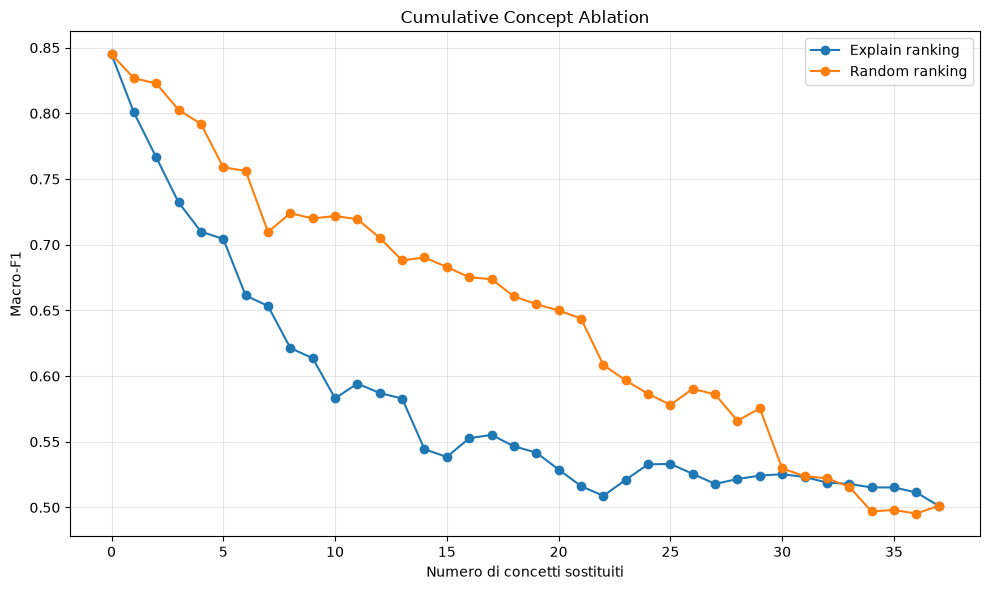

In [28]:
with torch.no_grad():
    base_probs = torch.sigmoid(
        model.task_head(predicted_concepts_tensor)
    )
    #calcola le probabilità dei 20 task usando i concetti predetti

base_selected = base_probs[
    row_index,
    task_id_tensor,
].cpu().numpy()
#seleziona per ogni esempio la probabilità del task a cui appartiene

test_labels_local = test_metrics["labels"]
#recupera le label corrette dei task

base_preds = (
    base_selected >= POSITIVE_THRESHOLD
).astype(int)
#trasforma le probabilità in predizioni binarie

baseline_macro_f1 = f1_score(
    test_labels_local,
    base_preds,
    average="macro",
)
#calcola la macro-F1 di riferimento senza interventi

print(
    f"Baseline macro-F1: {baseline_macro_f1:.4f}"
)


train_metrics_intervention = evaluate_model(
    model,
    train_loader,
)
#recupera i concetti predetti sul training set

train_pred_concepts = train_metrics_intervention[
    "concepts"
]
#usa la distribuzione dei concetti del training come riferimento per l'intervento


rng = np.random.default_rng(42)

replacement_values = np.zeros(
    (
        len(test_pred_concepts),
        len(CONCEPT_NAMES),
    ),
    dtype=np.float32,
)

for concept_index in range(
    len(CONCEPT_NAMES)
):

    replacement_values[
        :,
        concept_index,
    ] = rng.choice(
        train_pred_concepts[
            :,
            concept_index,
        ],
        size=len(test_pred_concepts),
        replace=True,
    )
#genera per ogni concetto valori di sostituzione campionati dalla distribuzione del training


concept_importance_rows = []

for concept_index, concept_name in enumerate(
    CONCEPT_NAMES
):

    intervened = (
        predicted_concepts_tensor.clone()
    )

    intervened[
        :,
        concept_index,
    ] = torch.tensor(
        replacement_values[
            :,
            concept_index,
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
    #sostituisce un concetto alla volta con valori plausibili

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            model.task_head(intervened)
        )
    #ricalcola le probabilità dei task dopo l'intervento

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ].cpu().numpy()
    #seleziona la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    intervened_macro_f1 = f1_score(
        test_labels_local,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 dopo la sostituzione del concetto

    concept_importance_rows.append(
        {
            "concept": concept_name,
            "macro_f1": intervened_macro_f1,
            "macro_f1_drop": (
                baseline_macro_f1
                - intervened_macro_f1
            ),
        }
    )
    #salva l'effetto dell'intervento


concept_importance = (
    pd.DataFrame(concept_importance_rows)
    .sort_values(
        "macro_f1_drop",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    concept_importance
)
#mostra l'importanza dei singoli concetti


concept_ranking = concept_importance[
    ["concept", "macro_f1_drop"]
].copy()

concept_ranking["rank"] = np.arange(
    1,
    len(concept_ranking) + 1,
)

concept_ranking = concept_ranking[
    ["rank", "concept", "macro_f1_drop"]
]
#riordina le colonne della classifica

display(
    concept_ranking
)


ranked_concepts = (
    concept_ranking["concept"].tolist()
)
#crea la lista dei concetti ordinati dal più importante al meno importante

concept_to_index = {
    name: idx
    for idx, name in enumerate(CONCEPT_NAMES)
}
#associa a ogni concetto il relativo indice


curve_rows = []

curve_rows.append(
    {
        "n_removed": 0,
        "macro_f1": baseline_macro_f1,
    }
)
#salva la macro-F1 di riferimento senza interventi


for k in range(
    1,
    len(ranked_concepts) + 1,
):

    intervened = (
        predicted_concepts_tensor.clone()
    )

    for concept_name in ranked_concepts[:k]:

        concept_index = (
            concept_to_index[concept_name]
        )

        intervened[
            :,
            concept_index,
        ] = torch.tensor(
            replacement_values[
                :,
                concept_index,
            ],
            dtype=torch.float32,
            device=DEVICE,
        )
    #sostituisce progressivamente i k concetti più importanti

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            model.task_head(intervened)
        )
    #ricalcola le probabilità dei task dopo l'intervento cumulativo

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ].cpu().numpy()
    #seleziona la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    macro_f1 = f1_score(
        test_labels_local,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 con i primi k concetti sostituiti

    curve_rows.append(
        {
            "n_removed": k,
            "macro_f1": macro_f1,
        }
    )


ablation_curve = pd.DataFrame(
    curve_rows
)
#crea la curva usando il ranking ottenuto dall'analisi

display(
    ablation_curve
)


random_ranked_concepts = rng.permutation(
    CONCEPT_NAMES
).tolist()
#crea un ranking casuale dei concetti


random_curve_rows = []

random_curve_rows.append(
    {
        "n_removed": 0,
        "macro_f1": baseline_macro_f1,
    }
)


for k in range(
    1,
    len(random_ranked_concepts) + 1,
):

    intervened = (
        predicted_concepts_tensor.clone()
    )

    for concept_name in (
        random_ranked_concepts[:k]
    ):

        concept_index = (
            concept_to_index[concept_name]
        )

        intervened[
            :,
            concept_index,
        ] = torch.tensor(
            replacement_values[
                :,
                concept_index,
            ],
            dtype=torch.float32,
            device=DEVICE,
        )
    #sostituisce progressivamente i k concetti secondo un ordine casuale

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            model.task_head(intervened)
        )
    #ricalcola le probabilità dei task dopo l'intervento cumulativo

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ].cpu().numpy()
    #seleziona la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    macro_f1 = f1_score(
        test_labels_local,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 con i primi k concetti sostituiti

    random_curve_rows.append(
        {
            "n_removed": k,
            "macro_f1": macro_f1,
        }
    )


random_ablation_curve = pd.DataFrame(
    random_curve_rows
)
#crea la curva usando il ranking casuale

display(
    random_ablation_curve
)


plt.figure(
    figsize=tuple(
        CONFIG["visualization"]["analysis_figsize"]
    )
)

plt.plot(
    ablation_curve["n_removed"],
    ablation_curve["macro_f1"],
    marker="o",
    label="Explain ranking",
)

plt.plot(
    random_ablation_curve["n_removed"],
    random_ablation_curve["macro_f1"],
    marker="o",
    label="Random ranking",
)

plt.xlabel("Numero di concetti sostituiti")
plt.ylabel("Macro-F1")
plt.title("Cumulative Concept Ablation")
plt.grid(
    True,
    alpha=CONFIG["visualization"]["grid_alpha"],
)
plt.legend()

plt.tight_layout()
plt.show()

## Robustezza a concetti rumorosi

Prendiamo i concetti predetti dal modello e li trasformiamo in valori 0/1, poi ne modifichiamo casualmente una certa percentuale per vedere quanto cambia l'accuratezza della classificazione.

In [29]:
test_task_ids = test_metrics["task_ids"]
#recupera il task a cui appartiene ogni esempio del test set

test_labels = test_metrics["labels"]
#recupera le label corrette dei task

def evaluate_with_binary_noise(
    noise_rate,
    seed=NOISE_SEED,
):
    rng = np.random.default_rng(seed)
    #inizializza il generatore casuale per rendere l'esperimento riproducibile

    noisy = (
        test_pred_concepts >= CONCEPT_THRESHOLD
    ).astype(np.float32)
    #trasforma i concetti predetti in valori binari 0/1

    flips = (
        rng.random(noisy.shape)
        < noise_rate
    )
    #seleziona casualmente i concetti da modificare in base alla percentuale di rumore

    noisy[flips] = 1.0 - noisy[flips]
    #inverte i concetti selezionati: 0 diventa 1 e 1 diventa 0

    noisy_tensor = torch.tensor(
        noisy,
        dtype=torch.float32,
        device=DEVICE,
    )
    #converte i concetti modificati in un tensore PyTorch

    with torch.no_grad():
        task_logits = model.task_head(
            noisy_tensor
        ).cpu().numpy()
    #calcola le predizioni dei task usando i concetti con rumore

    predictions = np.zeros(
        len(test_labels),
        dtype=np.float32,
    )
    #prepara un array per salvare la predizione finale di ogni esempio

    for task_id in range(TASK_COUNT):
        mask = test_task_ids == task_id
        #seleziona gli esempi appartenenti al task corrente

        predictions[mask] = (
            task_logits[mask, task_id] >= LOGIT_THRESHOLD
        ).astype(np.float32)
        #usa il logit del task corretto e lo trasforma in una predizione 0/1

    return accuracy_score(
        test_labels,
        predictions,
    )
    #calcola l'accuracy finale dopo aver introdotto il rumore nei concetti


noise_rates = CONFIG["analysis"]["noise_rates"]
#definisce le percentuali di concetti da invertire

robustness = pd.DataFrame(
    {
        "noise_rate": noise_rates,
        "task_accuracy": [
            evaluate_with_binary_noise(
                rate
            )
            for rate in noise_rates
        ],
    }
)

display(robustness)

robustness.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["linear_concept_noise"],
    index=False,
)

,noise_rate,task_accuracy
0,0.00,0.826
1,0.05,0.760
2,0.10,0.734
3,0.20,0.644
4,0.30,0.586


## Decomposizione degli errori

Confrontiamo la performance con i concetti predetti e con i concetti corretti. La differenza mostra quanto la qualità del bottleneck incide sulla classificazione finale.

In [30]:
#PERFORMANCE TESTA DI CLASSIFICAZIONE

oracle_concepts = torch.tensor(
    test_true_concepts,
    dtype=torch.float32,
    device=DEVICE,
)
#usa i concetti corretti del test set come input della task head

with torch.no_grad():
    oracle_task_logits = model.task_head(
        oracle_concepts
    ).cpu().numpy()
#calcola le predizioni dei task usando i concetti corretti, senza aggiornare i pesi

oracle_rows = []
#prepara una lista per salvare i risultati di ogni task

for task_id in range(TASK_COUNT):
    mask = test_task_ids == task_id
    #seleziona gli esempi appartenenti al task corrente

    y_true = test_labels[mask]
    #prende le label corrette del task corrente

    y_pred = (
        oracle_task_logits[mask, task_id] >= LOGIT_THRESHOLD
    ).astype(int)
    #trasforma il logit del task in una predizione 0/1 usando 0 come soglia

    oracle_rows.append(
        {
            "task_id": task_id,
            "task_name": TASK_NAMES[task_id],
            "accuracy": accuracy_score(
                y_true,
                y_pred,
            ),
            #calcola l'accuracy del task usando i concetti corretti

            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            #calcola l'F1 del task usando i concetti corretti
        }
    )

oracle_results = pd.DataFrame(oracle_rows)

display(oracle_results)

print(
    "Accuracy media oracle concetti:",
    round(
        oracle_results["accuracy"].mean(),
        3,
    ),
)

print(
    "F1 medio oracle concetti:",
    round(
        oracle_results["f1"].mean(),
        3,
    ),
)

oracle_map = oracle_results.set_index(
    "task_id"
)

model_map = test_task_results.set_index(
    "task_id"
)

decomposition = pd.DataFrame(
    {
        "task_id": range(TASK_COUNT),
        "task_name": [
            TASK_NAMES[index]
            for index in range(TASK_COUNT)
        ],
        "oracle_concept_accuracy": [
            oracle_map.loc[
                index,
                "accuracy",
            ]
            for index in range(TASK_COUNT)
        ],
        "predicted_concept_accuracy": [
            model_map.loc[
                index,
                "accuracy",
            ]
            for index in range(TASK_COUNT)
        ],
    }
)

decomposition["accuracy_drop"] = (
    decomposition[
        "oracle_concept_accuracy"
    ]
    - decomposition[
        "predicted_concept_accuracy"
    ]
)

display(
    decomposition.sort_values(
        "accuracy_drop",
        ascending=False,
    )
)

decomposition.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["linear_oracle_decomposition"],
    index=False,
)

,task_id,task_name,accuracy,f1
0,0,triangle vs any,0.92,0.875000
1,1,square vs any,0.96,0.947368
2,2,circle vs any,1.00,1.000000
3,3,red vs any,0.96,0.941176
4,4,green vs any,0.88,0.800000
5,5,blue vs any,0.92,0.923077
6,6,cyan vs any,0.84,0.777778
7,7,magenta vs any,0.68,0.636364
8,8,yellow vs any,0.96,0.909091
9,9,red triangle on the right,0.92,0.888889


Accuracy media oracle concetti: 0.85
F1 medio oracle concetti: 0.808


,task_id,task_name,oracle_concept_accuracy,predicted_concept_accuracy,accuracy_drop
15,15,house,0.68,0.60,0.08
16,16,car,0.92,0.84,0.08
13,13,"triangle and square, same color",0.76,0.68,0.08
0,0,triangle vs any,0.92,0.88,0.04
18,18,wagon,0.96,0.92,0.04
17,17,tower,0.96,0.92,0.04
3,3,red vs any,0.96,0.92,0.04
1,1,square vs any,0.96,0.96,0.00
2,2,circle vs any,1.00,1.00,0.00
4,4,green vs any,0.88,0.88,0.00


## Visualizzazione dei concetti

Con un vocabolario di 37 concetti possiamo leggere direttamente quali concetti risultano attivi per un'immagine e confrontarli con la task corrispondente.

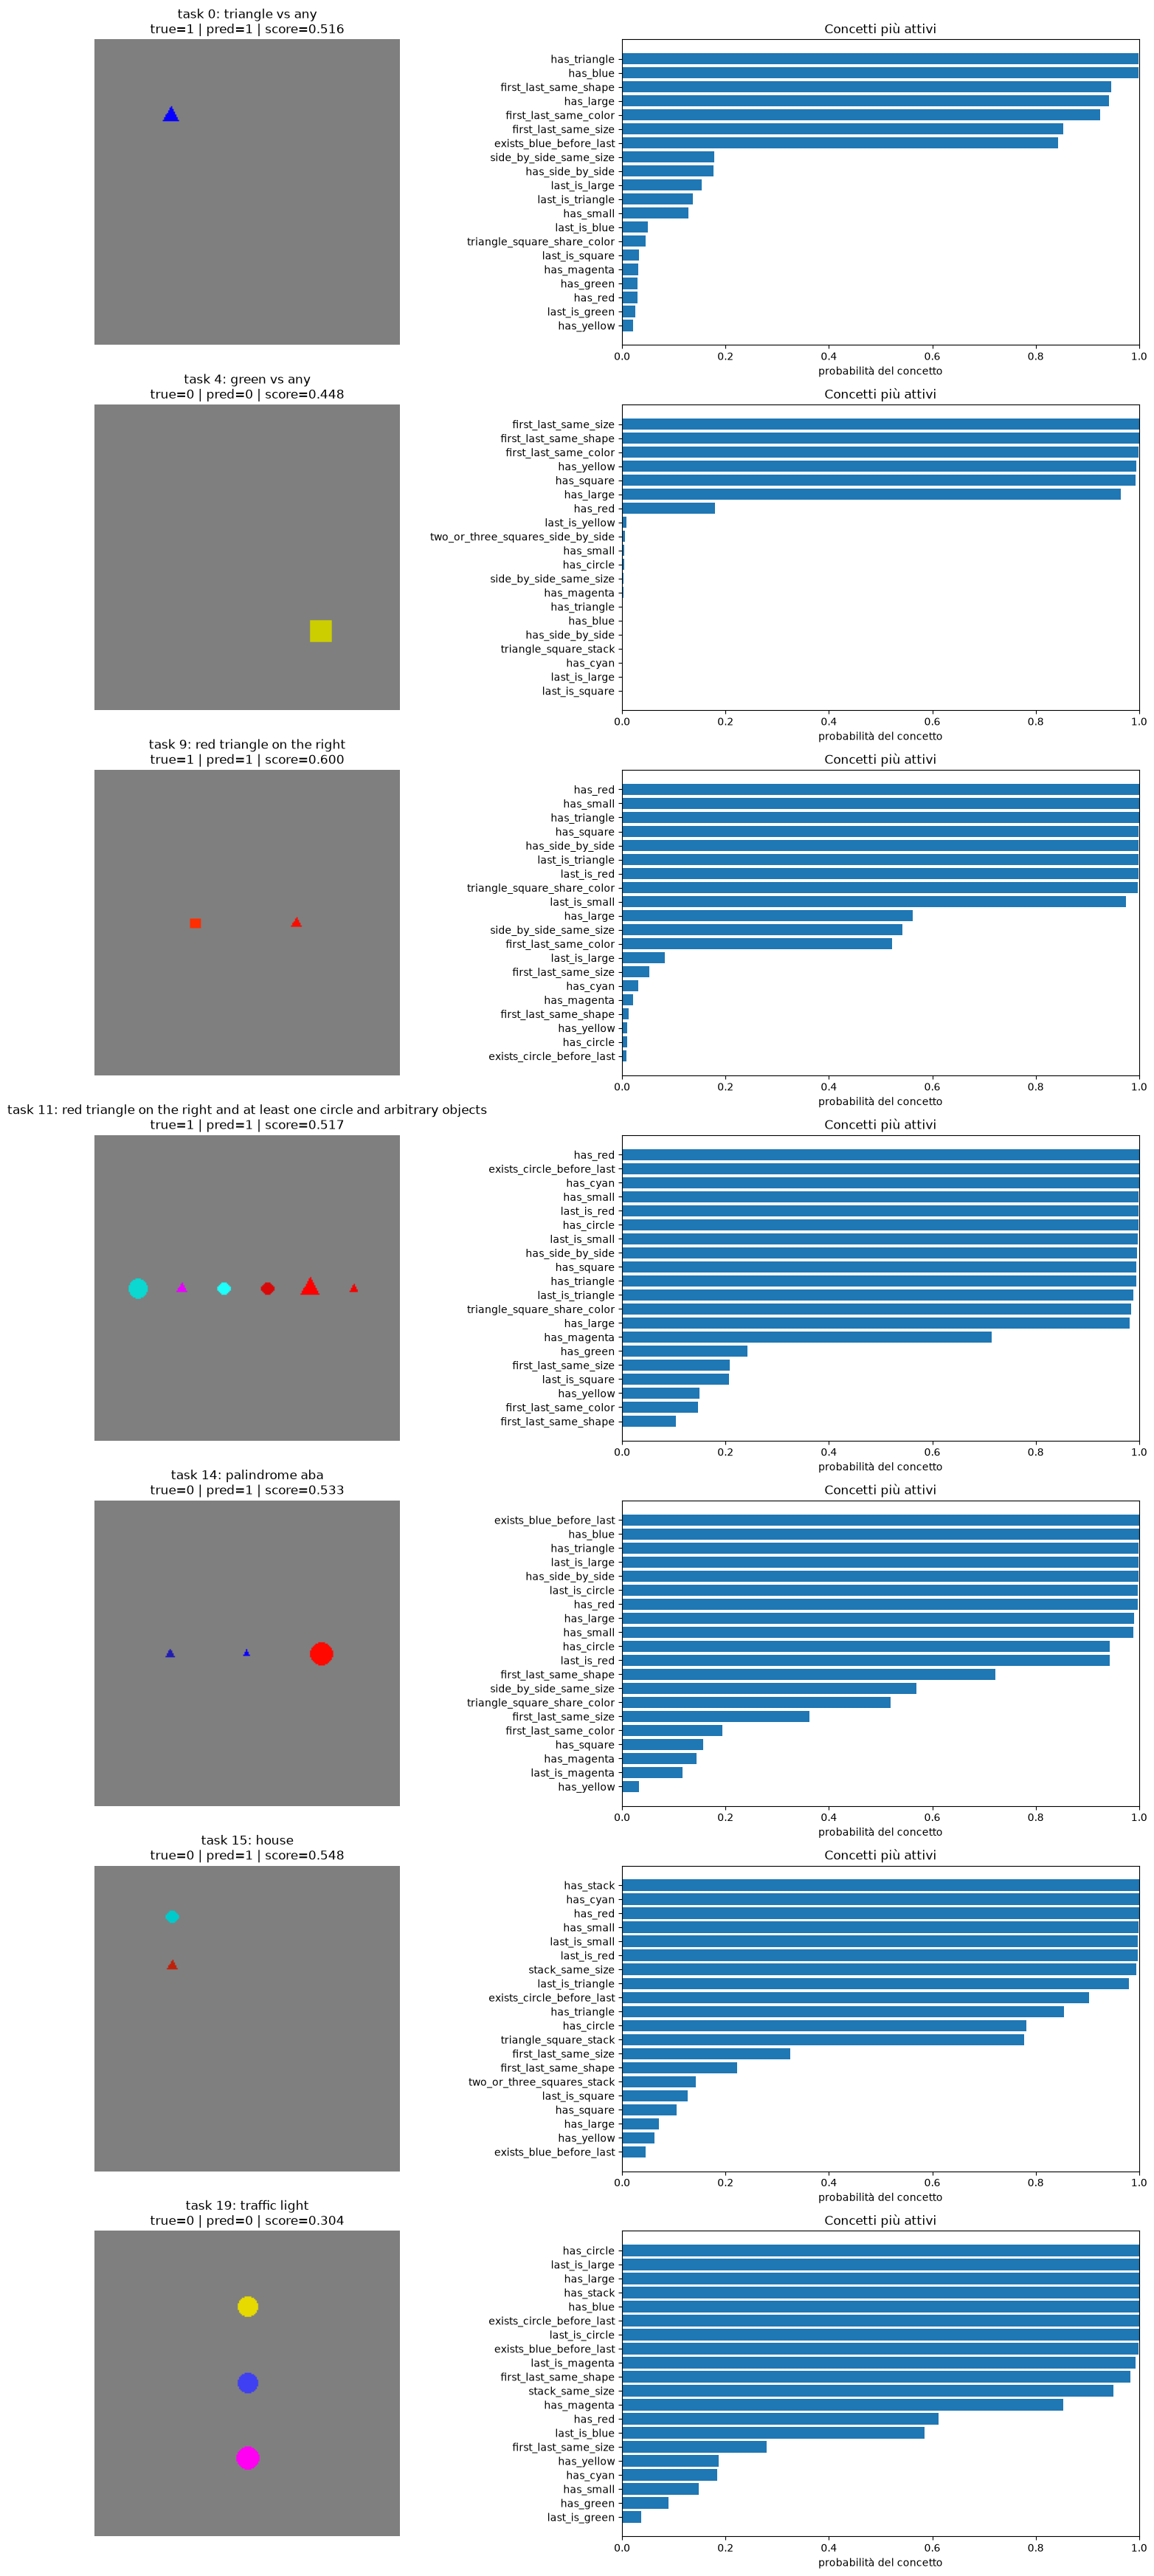

Plot salvato in: /home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_concept_cbm/plots/tasks_concepts_test_example_0.png


In [31]:
#PROBABILITA CONCETTI

@torch.no_grad()
def show_tasks_concepts(
    task_ids=tuple(CONFIG["visualization"]["task_ids"]),
    split=CONFIG["visualization"]["split"],
    top_k=CONFIG["visualization"]["top_k"],
    example_idx=CONFIG["visualization"]["linear_example_idx"],
):
    frame = splits[split].reset_index(
        drop=True
    )

    n = len(task_ids)

    fig = plt.figure(
        figsize=(CONFIG["visualization"]["fig_width"], CONFIG["visualization"]["fig_height_per_task"] * n)
    )

    for row_idx, task_id in enumerate(task_ids):

        task_rows = frame[
            frame["task_id"] == task_id
        ].reset_index(drop=True)

        if len(task_rows) == 0:
            print(
                f"task {task_id} non trovato"
            )
            continue

        if example_idx >= len(task_rows):
            print(
                f"task {task_id}: "
                f"example_idx={example_idx} "
                f"non disponibile "
                f"(esempi disponibili: {len(task_rows)})"
            )
            continue

        row = task_rows.iloc[
            example_idx
        ]

        image_path = (
            SPLIT_DIRS[split]
            / row["filename"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        x = eval_transform(
            image
        ).unsqueeze(0).to(DEVICE)

        _, concept_probs, task_logits = model(x)
        #calcola i concetti e le predizioni dei task

        concept_probs = (
            concept_probs[0]
            .cpu()
            .numpy()
        )

        task_probs = torch.sigmoid(
            task_logits[0]
        ).cpu().numpy()

        order = np.argsort(
            -concept_probs
        )[:top_k]
        #seleziona i concetti con probabilità più alta

        table = pd.DataFrame(
            {
                "concept": [
                    CONCEPT_NAMES[i]
                    for i in order
                ],
                "probability": [
                    float(concept_probs[i])
                    for i in order
                ],
                "active": [
                    bool(
                        concept_probs[i] >= CONCEPT_THRESHOLD
                    )
                    for i in order
                ],
            }
        )

        predicted = int(
            task_probs[task_id] >= POSITIVE_THRESHOLD
        )

        ax1 = fig.add_subplot(
            n,
            2,
            2 * row_idx + 1,
        )

        ax1.imshow(image)
        ax1.axis("off")

        ax1.set_title(
            f"task {task_id}: "
            f"{TASK_NAMES[task_id]}\n"
            f"true={int(row['label'])} | "
            f"pred={predicted} | "
            f"score={task_probs[task_id]:.3f}"
        )

        ax2 = fig.add_subplot(
            n,
            2,
            2 * row_idx + 2,
        )

        names = table[
            "concept"
        ].iloc[::-1]

        values = table[
            "probability"
        ].iloc[::-1]

        ax2.barh(
            names,
            values,
        )

        ax2.set_xlim(
            0,
            1,
        )

        ax2.set_xlabel(
            "probabilità del concetto"
        )

        ax2.set_title(
            "Concetti più attivi"
        )

    plt.tight_layout()

    plot_path = (
        PLOTS_DIR
        / CONFIG["outputs"]["linear_concepts_plot"].format(
            split=split,
            example_idx=example_idx,
        )
    )

    plt.savefig(
        plot_path,
        dpi=CONFIG["visualization"]["dpi"],
        bbox_inches="tight",
    )
    #salva il plot nella cartella dei risultati

    plt.show()
    plt.close(fig)

    print(
        f"Plot salvato in: {plot_path}"
    )


show_tasks_concepts(
    task_ids=CONFIG["visualization"]["task_ids"],
    split=CONFIG["visualization"]["split"],
    top_k=CONFIG["visualization"]["top_k"],
    example_idx=CONFIG["visualization"]["linear_example_idx"],
)

## Visualizzazione dei pesi della testa di classificazione

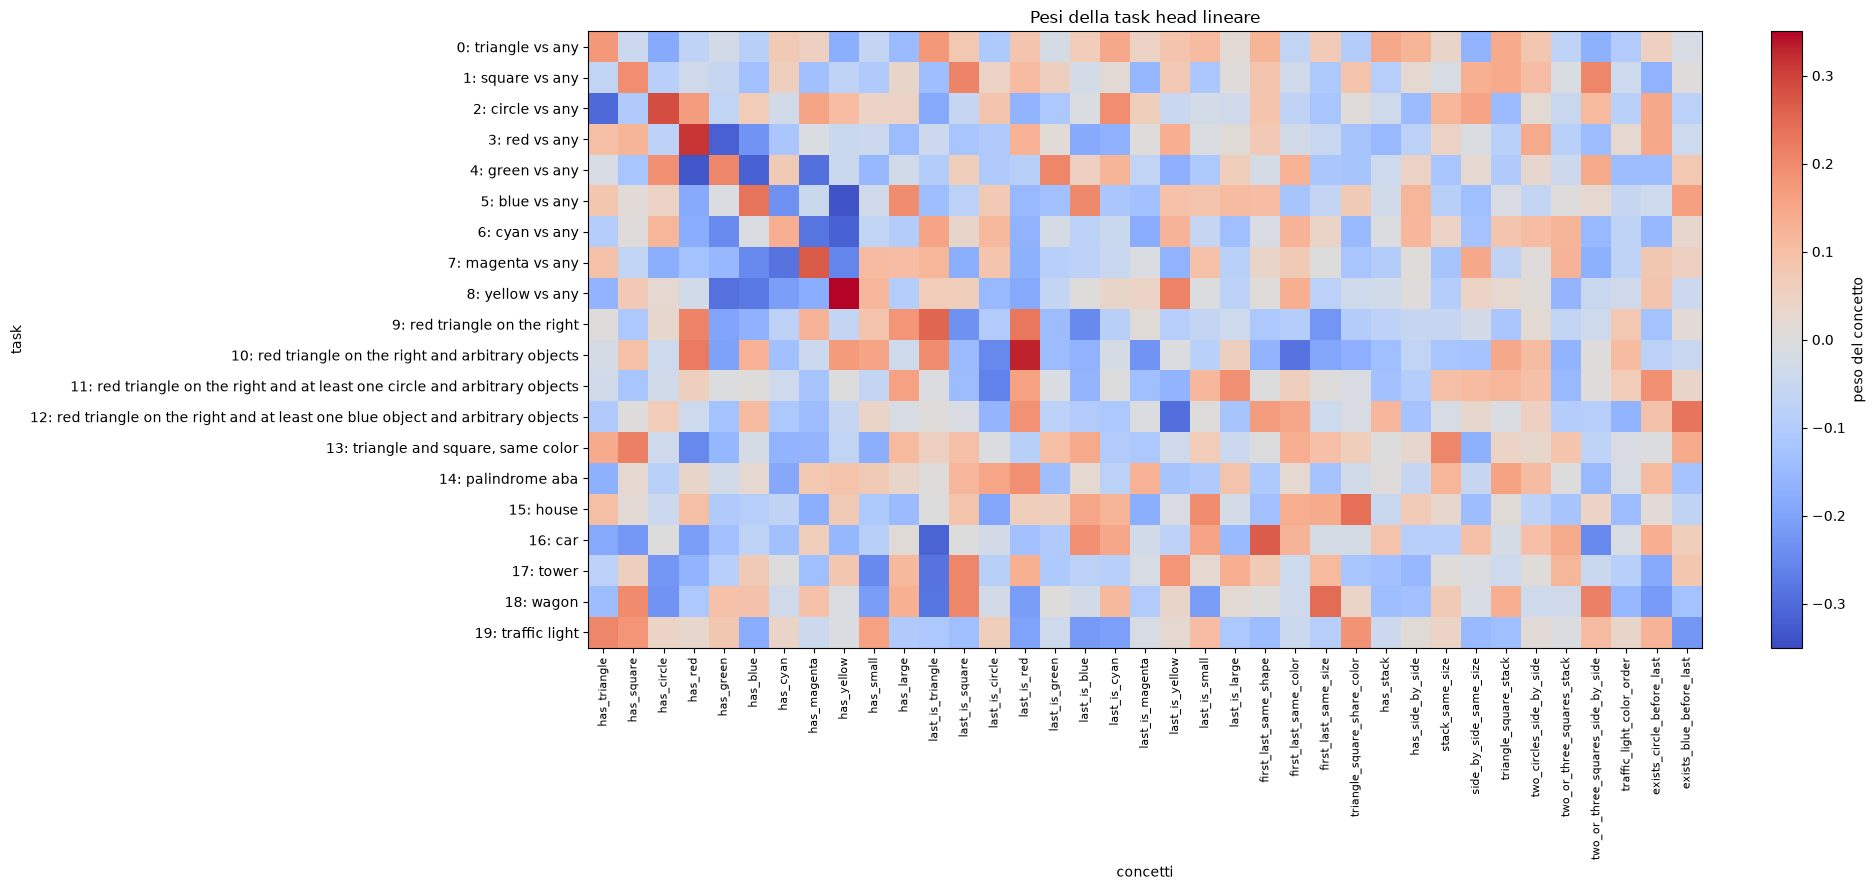

Plot salvato in: /home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_concept_cbm/plots/task_head_weights.png


In [32]:
#PESI TESTA LINEARE

PLOTS_DIR = ROOT / CONFIG["paths"]["plots_dir"]
PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
#crea la cartella in cui salvare i plot

task_weights = (
    model.task_head.weight
    .detach()
    .cpu()
    .numpy()
)
#estrae i 37 pesi associati a ciascun task

task_bias = (
    model.task_head.bias
    .detach()
    .cpu()
    .numpy()
)
#estrae il bias di ogni task

fig, ax = plt.subplots(
    figsize=tuple(CONFIG["visualization"]["weights_figsize"])
)

im = ax.imshow(
    task_weights,
    aspect="auto",
    cmap=CONFIG["visualization"]["cmap"],
    vmin=-np.max(
        np.abs(task_weights)
    ),
    vmax=np.max(
        np.abs(task_weights)
    ),
)
#mostra i pesi in una heatmap centrata sullo zero

ax.set_xticks(
    np.arange(len(CONCEPT_NAMES))
)

ax.set_xticklabels(
    CONCEPT_NAMES,
    rotation=90,
    fontsize=CONFIG["visualization"]["weights_tick_fontsize"],
)
#mostra i nomi dei 37 concetti

ax.set_yticks(
    np.arange(TASK_COUNT)
)

ax.set_yticklabels(
    [
        f"{i}: {TASK_NAMES[i]}"
        for i in range(TASK_COUNT)
    ]
)
#mostra i nomi dei 20 task

ax.set_xlabel(
    "concetti"
)

ax.set_ylabel(
    "task"
)

ax.set_title(
    "Pesi della task head lineare"
)

cbar = plt.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "peso del concetto"
)
#aggiunge la legenda dei pesi

plt.tight_layout()

weights_plot_path = (
    PLOTS_DIR
    / CONFIG["outputs"]["linear_weights_plot"]
)

plt.savefig(
    weights_plot_path,
    dpi=CONFIG["visualization"]["dpi"],
    bbox_inches="tight",
)
#salva la heatmap nella cartella dei risultati

plt.show()
plt.close(fig)

print(
    f"Plot salvato in: {weights_plot_path}"
)

## Salvataggio della configurazione

Salviamo il vocabolario dei concetti, il checkpoint e gli iperparametri principali.

In [33]:
config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "task_loss_weight": TASK_LOSS_WEIGHT,
    "backbone": LINEAR_VARIANT,
    "n_concepts": len(CONCEPT_NAMES),
    "concept_names": CONCEPT_NAMES,
    "task_names": TASK_NAMES,
    "best_val_macro_f1": float(
        best_val_f1
    ),
}

with open(
    RESULTS_DIR / CONFIG["outputs"]["linear_config_json"],
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config,
        file,
        indent=2,
    )

print(
    "Checkpoint:",
    CHECKPOINT_DIR
    / CONFIG["outputs"]["linear_checkpoint"],
)

print(
    "Config:",
    RESULTS_DIR
    / "concept_cbm_config.json",
)

Checkpoint: /home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_concept_cbm/checkpoints/concept_cbm_best.pt
Config: /home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_concept_cbm/concept_cbm_config.json


## Task Head MLP

Sono andato poi a testare l'architettura cambiando la testa di classificazione e, al posto di un layer lineare, ho introdotto un MLP.

In [34]:
#CAMBIAMO TESTA


class ConceptCBMMLP(nn.Module):

    def __init__(
        self,
        n_concepts,
        n_tasks=MLP_N_TASKS,
        hidden_dim=MLP_HIDDEN_DIM,
    ):
        super().__init__()

        if CONFIG["models"]["mlp"]["backbone"] != "resnet18":
            raise ValueError("Only resnet18 is supported by this notebook.")

        backbone = models.resnet18(
            weights=getattr(
                models.ResNet18_Weights,
                MLP_PRETRAINED_WEIGHTS,
            )
        )
        #nuova ResNet inizializzata con i pesi pretrained 

        feature_dim = backbone.fc.in_features

        backbone.fc = nn.Identity()
        #rimuoviamo la classificazione originale

        self.backbone = backbone

        self.concept_layer = nn.Linear(
            feature_dim,
            n_concepts,
        )
        #trasforma la rappresentazione visiva nei concetti

        self.task_head = nn.Sequential(
            nn.Linear(
                n_concepts,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_dim,
                n_tasks,
            ),
        )
        #MLP che combina i concetti per ottenere le predizioni dei task

    def forward(self, x):

        features = self.backbone(x)

        concept_logits = self.concept_layer(
            features
        )

        concepts = torch.sigmoid(
            concept_logits
        )

        task_logits = self.task_head(
            concepts
        )

        return (
            concept_logits,
            concepts,
            task_logits,
        )


model_mlp = ConceptCBMMLP(
    n_concepts=len(CONCEPT_NAMES),
    n_tasks=MLP_N_TASKS,
    hidden_dim=MLP_HIDDEN_DIM,
).to(DEVICE)
#crea il nuovo CBM con testa MLP

print(
    "Nuovo CBM con MLP"
)

print(
    "Numero di concetti:",
    len(CONCEPT_NAMES),
)

print(
    "Feature ResNet:",
    model_mlp.concept_layer.in_features,
)


if OPTIMIZER_NAME != "AdamW":
    raise ValueError(
        "Only AdamW is supported by this notebook."
    )

optimizer_mlp = torch.optim.AdamW(
    model_mlp.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
#aggiorniamo end-to-end ResNet, concept layer e MLP


history_mlp = []

best_val_f1_mlp = -np.inf
best_state_mlp = None

patience_count = 0


for epoch in range(
    1,
    EPOCHS + 1,
):

    model_mlp.train()

    train_loss_sum = 0.0
    train_examples = 0

    for (
        images,
        task_ids,
        labels,
        concepts_true,
    ) in train_loader:

        images = images.to(DEVICE)
        task_ids = task_ids.to(DEVICE)
        labels = labels.to(
            DEVICE
        ).float()
        concepts_true = concepts_true.to(
            DEVICE
        )

        optimizer_mlp.zero_grad(
            set_to_none=True
        )

        concept_logits, concepts, task_logits = (
            model_mlp(images)
        )

        concept_loss = criterion_concept(
            concept_logits,
            concepts_true,
        )

        task_loss = task_loss_from_logits(
            task_logits,
            task_ids,
            labels,
        )

        loss = (
            concept_loss
            + TASK_LOSS_WEIGHT * task_loss
        )
        #combiniamo la loss sui concetti e quella sui task

        loss.backward()

        optimizer_mlp.step()

        train_loss_sum += (
            float(loss.item())
            * len(labels)
        )

        train_examples += len(labels)


    train_loss = (
        train_loss_sum
        / max(train_examples, 1)
    )


    val_metrics_mlp = evaluate_model(
        model_mlp,
        val_loader,
    )
    #valutiamo il modello sulla validation set

    history_mlp.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics_mlp["loss"],
            "val_macro_f1": val_metrics_mlp[
                "macro_f1"
            ],
        }
    )

    print(
        f"epoch {epoch:02d} | "
        f"train loss={train_loss:.4f} | "
        f"val loss={val_metrics_mlp['loss']:.4f} | "
        f"val macro-F1={val_metrics_mlp['macro_f1']:.4f}"
    )


    if (
        val_metrics_mlp["macro_f1"]
        > best_val_f1_mlp
    ):

        best_val_f1_mlp = (
            val_metrics_mlp["macro_f1"]
        )

        best_state_mlp = {
            key: value.detach()
            .cpu()
            .clone()
            for key, value
            in model_mlp.state_dict().items()
        }

        patience_count = 0

    else:

        patience_count += 1


    if (
        patience_count
        >= EARLY_STOPPING_PATIENCE
    ):

        print("early stopping")
        break


if best_state_mlp is None:
    raise RuntimeError(
        "Nessun checkpoint MLP valido trovato."
    )


model_mlp.load_state_dict(
    best_state_mlp
)
#ripristiniamo il checkpoint con la migliore macro-F1 di validation


mlp_head = model_mlp.task_head
#salviamo un riferimento alla task head MLP per le analisi successive


# TEST

test_metrics_mlp = evaluate_model(
    model_mlp,
    test_loader,
)
#valutiamo il modello finale sul test set

mlp_results = test_metrics_mlp[
    "task_results"
]

display(
    mlp_results
)

print(
    "Accuracy media MLP:",
    round(
        mlp_results["accuracy"].mean(),
        3,
    ),
)

print(
    "F1 medio MLP:",
    round(
        mlp_results["f1"].mean(),
        3,
    ),
)

Nuovo CBM con MLP
Numero di concetti: 37
Feature ResNet: 512
epoch 01 | train loss=0.8733 | val loss=0.8146 | val macro-F1=0.3738
epoch 02 | train loss=0.6213 | val loss=0.5361 | val macro-F1=0.4056
epoch 03 | train loss=0.5262 | val loss=0.4941 | val macro-F1=0.4239
epoch 04 | train loss=0.4652 | val loss=0.4526 | val macro-F1=0.5012
epoch 05 | train loss=0.4484 | val loss=0.5489 | val macro-F1=0.5396
epoch 06 | train loss=0.4386 | val loss=0.4176 | val macro-F1=0.6735
epoch 07 | train loss=0.3844 | val loss=0.3549 | val macro-F1=0.7541
epoch 08 | train loss=0.3410 | val loss=0.3336 | val macro-F1=0.7962
epoch 09 | train loss=0.3180 | val loss=0.3138 | val macro-F1=0.8332
epoch 10 | train loss=0.3054 | val loss=0.3107 | val macro-F1=0.8452
epoch 11 | train loss=0.2923 | val loss=0.3062 | val macro-F1=0.8356
epoch 12 | train loss=0.2734 | val loss=0.2862 | val macro-F1=0.8513
epoch 13 | train loss=0.2674 | val loss=0.2829 | val macro-F1=0.8824
epoch 14 | train loss=0.2489 | val loss=0.

,task_id,task_name,accuracy,f1
0,0,triangle vs any,1.00,1.000000
1,1,square vs any,1.00,1.000000
2,2,circle vs any,0.92,0.933333
3,3,red vs any,1.00,1.000000
4,4,green vs any,1.00,1.000000
5,5,blue vs any,1.00,1.000000
6,6,cyan vs any,0.88,0.823529
7,7,magenta vs any,1.00,1.000000
8,8,yellow vs any,1.00,1.000000
9,9,red triangle on the right,0.96,0.941176


Accuracy media MLP: 0.912
F1 medio MLP: 0.904


## Qualità del Bottleneck

In [35]:
#QUALITA' DEL BOTTLENECK - CBM MLP

test_true_concepts_mlp = splits["test"][
    CONCEPT_NAMES
].to_numpy(dtype=np.float32)
#prende le label corrette dei concetti dal test set

test_pred_concepts_mlp = test_metrics_mlp[
    "concepts"
]
#recupera i concetti predetti dal CBM MLP

test_pred_binary_mlp = (
    test_pred_concepts_mlp >= CONCEPT_THRESHOLD
).astype(np.float32)
#trasforma le probabilità predette in valori 0/1 usando 0.5 come soglia

concept_rows_mlp = []

for index, name in enumerate(CONCEPT_NAMES):

    concept_rows_mlp.append(
        {
            "concept": name,
            "f1": f1_score(
                test_true_concepts_mlp[:, index],
                test_pred_binary_mlp[:, index],
                zero_division=0,
            ),
            #calcola l'F1 del singolo concetto

            "positive_rate": float(
                test_true_concepts_mlp[:, index].mean()
            ),
            #calcola la percentuale di esempi in cui il concetto è presente
        }
    )


concept_results_mlp = (
    pd.DataFrame(concept_rows_mlp)
    .sort_values(
        "f1",
        ascending=False,
    )
)
#crea la tabella dei risultati ordinata per F1

display(
    concept_results_mlp
)
#mostra la tabella dei risultati

print(
    "F1 medio dei concetti MLP:",
    round(
        concept_results_mlp["f1"].mean(),
        3,
    ),
)

concept_results_mlp.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["mlp_concept_results"],
    index=False,
)
#salva i risultati

,concept,f1,positive_rate
3,has_red,1.000000,0.342
12,last_is_square,1.000000,0.184
11,last_is_triangle,1.000000,0.206
8,has_yellow,1.000000,0.232
5,has_blue,1.000000,0.290
15,last_is_green,1.000000,0.072
34,traffic_light_color_order,1.000000,0.006
21,last_is_large,0.996416,0.278
13,last_is_circle,0.993789,0.160
2,has_circle,0.989817,0.496


F1 medio dei concetti MLP: 0.934


## Interventi sui Concetti

In [36]:
#INTERVENTO SUI CONCETTI

with torch.no_grad():
    base_probs = torch.sigmoid(
        mlp_head(
            predicted_concepts_tensor
        )
    )
#calcola le probabilità di base della MLP

base_selected = base_probs[
    row_index,
    task_id_tensor,
]
#seleziona la probabilità del task corretto

intervention_rows = []

for concept_index, concept_name in enumerate(
    CONCEPT_NAMES
):
    intervened = (
        predicted_concepts_tensor.clone()
    )

    intervened[:, concept_index] = INTERVENTION_VALUE
    #disattiva un concetto alla volta

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            mlp_head(
                intervened
            )
        )
    #ricalcola la predizione dopo l'intervento

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ]

    delta = (
        base_selected
        - intervened_selected
    ).cpu().numpy()
    #misura quanto cambia la probabilità del task

    intervention_rows.append(
        {
            "concept": concept_name,
            "mean_score_drop": float(
                delta.mean()
            ),
            "mean_abs_change": float(
                np.abs(delta).mean()
            ),
        }
    )
    #salva l'effetto medio dell'intervento

mlp_intervention_results = (
    pd.DataFrame(intervention_rows)
    .sort_values(
        "mean_abs_change",
        ascending=False,
    )
)

display(
    mlp_intervention_results
)

mlp_intervention_results.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["mlp_concept_interventions"],
    index=False,
)

#analizziamo l'intervento separatamente per task

mlp_per_task_rows = []

for concept_index, concept_name in enumerate(
    CONCEPT_NAMES
):
    intervened = (
        predicted_concepts_tensor.clone()
    )

    intervened[:, concept_index] = INTERVENTION_VALUE
    #disattiva un concetto alla volta

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            mlp_head(
                intervened
            )
        )

    intervened_selected = intervened_probs[
        row_index,
        task_id_tensor,
    ]

    delta = (
        base_selected
        - intervened_selected
    ).cpu().numpy()
    #calcola il cambiamento della probabilità

    for task_id in range(TASK_COUNT):
        mask = test_task_ids == task_id

        if not np.any(mask):
            continue

        mlp_per_task_rows.append(
            {
                "task_id": task_id,
                "task": TASK_NAMES[task_id],
                "concept": concept_name,
                "mean_abs_change": float(
                    np.abs(delta[mask]).mean()
                ),
                "mean_score_drop": float(
                    delta[mask].mean()
                ),
            }
        )
        #salva l'effetto del concetto sul task corrente

mlp_intervention_by_task = pd.DataFrame(
    mlp_per_task_rows
)

for task_id in CONFIG["analysis"]["per_task_ids_mlp"]:
    print(
        f"\nTask {task_id}: "
        f"{TASK_NAMES[task_id]}"
    )

    display(
        mlp_intervention_by_task[
            mlp_intervention_by_task["task_id"]
            == task_id
        ]
        .sort_values(
            "mean_abs_change",
            ascending=False,
        )
        .head(CONFIG["analysis"]["per_task_top_k"])
    )

mlp_intervention_by_task.to_csv(
    RESULTS_DIR
    / CONFIG["outputs"]["mlp_concept_interventions_by_task"],
    index=False,
)

,concept,mean_score_drop,mean_abs_change
3,has_red,0.022052,0.035468
14,last_is_red,0.024214,0.035362
1,has_square,0.007931,0.030688
2,has_circle,-0.003396,0.026702
0,has_triangle,-0.002325,0.024738
11,last_is_triangle,0.016312,0.022224
10,has_large,-0.015238,0.021884
5,has_blue,0.002308,0.018859
24,first_last_same_size,-0.002554,0.017726
7,has_magenta,-0.007982,0.016463



Task 9: red triangle on the right


,task_id,task,concept,mean_abs_change,mean_score_drop
229,9,red triangle on the right,last_is_triangle,0.093899,0.093899
69,9,red triangle on the right,has_red,0.086594,0.086594
289,9,red triangle on the right,last_is_red,0.081614,0.081614
209,9,red triangle on the right,has_large,0.048700,-0.048700
589,9,red triangle on the right,side_by_side_same_size,0.045038,-0.045038
169,9,red triangle on the right,has_yellow,0.026466,-0.026466
509,9,red triangle on the right,triangle_square_share_color,0.020881,-0.020881
409,9,red triangle on the right,last_is_small,0.018170,-0.018170
9,9,red triangle on the right,has_triangle,0.017709,0.016194
89,9,red triangle on the right,has_green,0.016508,-0.016508



Task 13: triangle and square, same color


,task_id,task,concept,mean_abs_change,mean_score_drop
33,13,"triangle and square, same color",has_square,0.110099,0.110099
253,13,"triangle and square, same color",last_is_square,0.061541,0.061541
513,13,"triangle and square, same color",triangle_square_share_color,0.034362,0.034362
293,13,"triangle and square, same color",last_is_red,0.034223,-0.034223
613,13,"triangle and square, same color",triangle_square_stack,0.031423,0.031423
73,13,"triangle and square, same color",has_red,0.027405,-0.027405
13,13,"triangle and square, same color",has_triangle,0.022461,0.022461
133,13,"triangle and square, same color",has_cyan,0.020131,-0.020131
53,13,"triangle and square, same color",has_circle,0.018353,-0.018353
153,13,"triangle and square, same color",has_magenta,0.018276,-0.018276



Task 14: palindrome aba


,task_id,task,concept,mean_abs_change,mean_score_drop
14,14,palindrome aba,has_triangle,0.037075,-0.037075
34,14,palindrome aba,has_square,0.018033,-0.018033
114,14,palindrome aba,has_blue,0.017461,-0.017461
54,14,palindrome aba,has_circle,0.015831,0.015831
294,14,palindrome aba,last_is_red,0.013693,-0.013691
274,14,palindrome aba,last_is_circle,0.013627,0.013627
414,14,palindrome aba,last_is_small,0.013360,0.013360
234,14,palindrome aba,last_is_triangle,0.013230,-0.013230
74,14,palindrome aba,has_red,0.011435,0.011435
434,14,palindrome aba,last_is_large,0.009776,-0.009776



Task 19: traffic light


,task_id,task,concept,mean_abs_change,mean_score_drop
119,19,traffic light,has_blue,0.055596,-0.055596
179,19,traffic light,has_yellow,0.040911,0.040911
59,19,traffic light,has_circle,0.038459,-0.038459
699,19,traffic light,traffic_light_color_order,0.032886,0.032886
439,19,traffic light,last_is_large,0.029482,-0.029482
139,19,traffic light,has_cyan,0.027320,-0.027320
719,19,traffic light,exists_circle_before_last,0.022235,-0.021802
99,19,traffic light,has_green,0.021053,0.021053
299,19,traffic light,last_is_red,0.018363,-0.018363
79,19,traffic light,has_red,0.018170,0.018170


Baseline macro-F1 MLP: 0.9101


,concept,macro_f1,macro_f1_drop
0,has_cyan,0.883231,0.026906
1,has_circle,0.887328,0.022809
2,has_green,0.887468,0.022669
3,has_yellow,0.887468,0.022669
4,has_triangle,0.887736,0.022400
5,has_blue,0.889163,0.020974
6,has_square,0.889163,0.020974
7,has_magenta,0.889446,0.020691
8,has_red,0.891143,0.018993
9,last_is_square,0.897882,0.012254


,rank,concept,macro_f1_drop
0,1,has_cyan,0.026906
1,2,has_circle,0.022809
2,3,has_green,0.022669
3,4,has_yellow,0.022669
4,5,has_triangle,0.022400
5,6,has_blue,0.020974
6,7,has_square,0.020974
7,8,has_magenta,0.020691
8,9,has_red,0.018993
9,10,last_is_square,0.012254


,n_removed,macro_f1
0,0,0.910137
1,1,0.883231
2,2,0.860427
3,3,0.828817
4,4,0.799354
5,5,0.769647
6,6,0.759389
7,7,0.735183
8,8,0.729618
9,9,0.714919


,n_removed,macro_f1
0,0,0.910137
1,1,0.905824
2,2,0.905705
3,3,0.876342
4,4,0.872220
5,5,0.845536
6,6,0.845536
7,7,0.823633
8,8,0.816969
9,9,0.809934


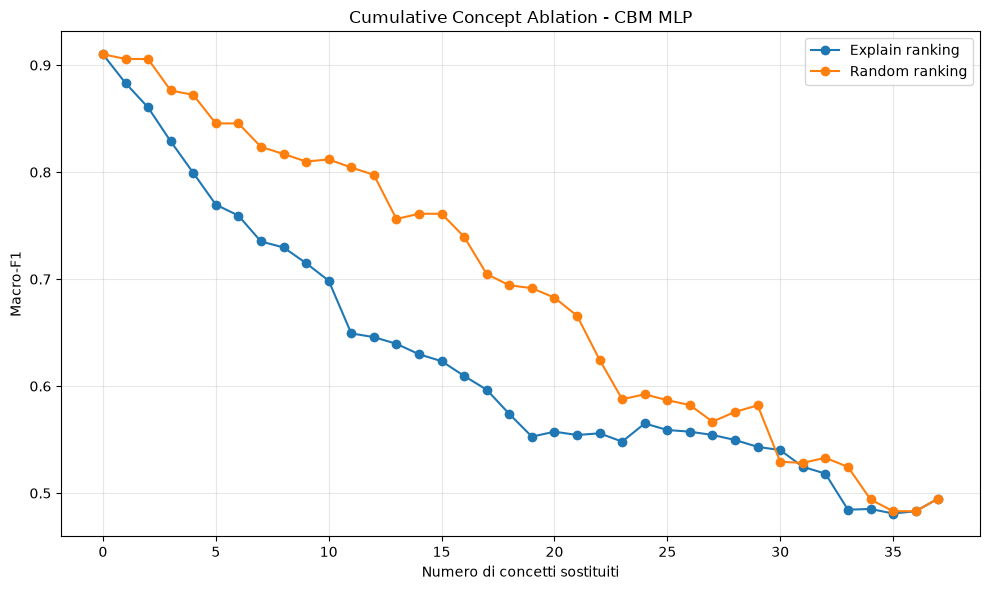

In [37]:
#IMPORTANZA DEI CONCETTI

test_pred_concepts_mlp = test_metrics_mlp["concepts"]
#recupera i concetti predetti dal CBM MLP

predicted_concepts_tensor_mlp = torch.tensor(
    test_pred_concepts_mlp,
    dtype=torch.float32,
    device=DEVICE,
)
#converte i concetti predetti in un tensore

test_task_ids_mlp = test_metrics_mlp["task_ids"]
#recupera il task associato a ogni esempio del test set

task_id_tensor_mlp = torch.tensor(
    test_task_ids_mlp,
    dtype=torch.long,
    device=DEVICE,
)

row_index_mlp = torch.arange(
    len(test_task_ids_mlp),
    device=DEVICE,
)
#crea gli indici per selezionare il task corretto


with torch.no_grad():
    base_probs_mlp = torch.sigmoid(
        mlp_head(
            predicted_concepts_tensor_mlp
        )
    )
#calcola le probabilità dei task usando i concetti predetti

base_selected_mlp = base_probs_mlp[
    row_index_mlp,
    task_id_tensor_mlp,
].cpu().numpy()
#seleziona per ogni esempio la probabilità del task corretto

test_labels_mlp = test_metrics_mlp["labels"]
#recupera le label corrette dei task

base_preds_mlp = (
    base_selected_mlp >= POSITIVE_THRESHOLD
).astype(int)
#trasforma le probabilità in predizioni binarie

baseline_macro_f1_mlp = f1_score(
    test_labels_mlp,
    base_preds_mlp,
    average="macro",
)
#calcola la macro-F1 di riferimento

print(
    f"Baseline macro-F1 MLP: "
    f"{baseline_macro_f1_mlp:.4f}"
)


train_metrics_mlp = evaluate_model(
    model_mlp,
    train_loader,
)
#recupera i concetti predetti dal modello sul training set

train_pred_concepts_mlp = train_metrics_mlp[
    "concepts"
]
#usa la distribuzione dei concetti del training come riferimento


rng_mlp = np.random.default_rng(42)

replacement_values_mlp = np.zeros(
    (
        len(test_pred_concepts_mlp),
        len(CONCEPT_NAMES),
    ),
    dtype=np.float32,
)

for concept_index in range(
    len(CONCEPT_NAMES)
):

    replacement_values_mlp[
        :,
        concept_index,
    ] = rng_mlp.choice(
        train_pred_concepts_mlp[
            :,
            concept_index,
        ],
        size=len(test_pred_concepts_mlp),
        replace=True,
    )
#genera per ogni concetto valori di sostituzione presi dalla distribuzione del training


concept_importance_rows_mlp = []

for concept_index, concept_name in enumerate(
    CONCEPT_NAMES
):

    intervened = (
        predicted_concepts_tensor_mlp.clone()
    )

    intervened[
        :,
        concept_index,
    ] = torch.tensor(
        replacement_values_mlp[
            :,
            concept_index,
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
    #sostituisce un concetto alla volta con valori plausibili

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            mlp_head(
                intervened
            )
        )
    #ricalcola le probabilità dei task dopo l'intervento

    intervened_selected = intervened_probs[
        row_index_mlp,
        task_id_tensor_mlp,
    ].cpu().numpy()
    #seleziona per ogni esempio la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    intervened_macro_f1 = f1_score(
        test_labels_mlp,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 dopo la sostituzione del concetto

    concept_importance_rows_mlp.append(
        {
            "concept": concept_name,
            "macro_f1": intervened_macro_f1,
            "macro_f1_drop": (
                baseline_macro_f1_mlp
                - intervened_macro_f1
            ),
        }
    )
    #salva la variazione di macro-F1 causata dall'intervento


concept_importance_mlp = (
    pd.DataFrame(
        concept_importance_rows_mlp
    )
    .sort_values(
        "macro_f1_drop",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    concept_importance_mlp
)
#mostra l'importanza dei singoli concetti


concept_ranking_mlp = concept_importance_mlp[
    ["concept", "macro_f1_drop"]
].copy()

concept_ranking_mlp["rank"] = np.arange(
    1,
    len(concept_ranking_mlp) + 1,
)

concept_ranking_mlp = concept_ranking_mlp[
    ["rank", "concept", "macro_f1_drop"]
]
#riordina le colonne della classifica

display(
    concept_ranking_mlp
)


ranked_concepts_mlp = (
    concept_ranking_mlp["concept"]
    .tolist()
)
#crea la lista dei concetti ordinati dal più importante al meno importante

concept_to_index_mlp = {
    name: idx
    for idx, name in enumerate(CONCEPT_NAMES)
}
#associa a ogni concetto il relativo indice


curve_rows_mlp = []

curve_rows_mlp.append(
    {
        "n_removed": 0,
        "macro_f1": baseline_macro_f1_mlp,
    }
)
#salva la macro-F1 di riferimento senza interventi


for k in range(
    1,
    len(ranked_concepts_mlp) + 1,
):

    intervened = (
        predicted_concepts_tensor_mlp.clone()
    )

    for concept_name in (
        ranked_concepts_mlp[:k]
    ):

        concept_index = (
            concept_to_index_mlp[concept_name]
        )

        intervened[
            :,
            concept_index,
        ] = torch.tensor(
            replacement_values_mlp[
                :,
                concept_index,
            ],
            dtype=torch.float32,
            device=DEVICE,
        )
    #sostituisce progressivamente i k concetti più importanti

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            mlp_head(
                intervened
            )
        )
    #ricalcola le probabilità dei task dopo l'intervento cumulativo

    intervened_selected = intervened_probs[
        row_index_mlp,
        task_id_tensor_mlp,
    ].cpu().numpy()
    #seleziona la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    macro_f1 = f1_score(
        test_labels_mlp,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 con i primi k concetti sostituiti

    curve_rows_mlp.append(
        {
            "n_removed": k,
            "macro_f1": macro_f1,
        }
    )


ablation_curve_mlp = pd.DataFrame(
    curve_rows_mlp
)
#crea la curva usando il ranking ottenuto dall'analisi

display(
    ablation_curve_mlp
)


random_ranked_concepts_mlp = rng_mlp.permutation(
    CONCEPT_NAMES
).tolist()
#crea un ranking casuale dei concetti


random_curve_rows_mlp = []

random_curve_rows_mlp.append(
    {
        "n_removed": 0,
        "macro_f1": baseline_macro_f1_mlp,
    }
)


for k in range(
    1,
    len(random_ranked_concepts_mlp) + 1,
):

    intervened = (
        predicted_concepts_tensor_mlp.clone()
    )

    for concept_name in (
        random_ranked_concepts_mlp[:k]
    ):

        concept_index = (
            concept_to_index_mlp[concept_name]
        )

        intervened[
            :,
            concept_index,
        ] = torch.tensor(
            replacement_values_mlp[
                :,
                concept_index,
            ],
            dtype=torch.float32,
            device=DEVICE,
        )
    #sostituisce progressivamente i k concetti secondo un ordine casuale

    with torch.no_grad():
        intervened_probs = torch.sigmoid(
            mlp_head(
                intervened
            )
        )
    #ricalcola le probabilità dei task dopo l'intervento cumulativo

    intervened_selected = intervened_probs[
        row_index_mlp,
        task_id_tensor_mlp,
    ].cpu().numpy()
    #seleziona la probabilità del task corretto

    intervened_preds = (
        intervened_selected >= POSITIVE_THRESHOLD
    ).astype(int)
    #trasforma le probabilità in predizioni binarie

    macro_f1 = f1_score(
        test_labels_mlp,
        intervened_preds,
        average="macro",
    )
    #calcola la macro-F1 con i primi k concetti sostituiti

    random_curve_rows_mlp.append(
        {
            "n_removed": k,
            "macro_f1": macro_f1,
        }
    )


random_ablation_curve_mlp = pd.DataFrame(
    random_curve_rows_mlp
)
#crea la curva usando il ranking casuale

display(
    random_ablation_curve_mlp
)


plt.figure(
    figsize=tuple(
        CONFIG["visualization"]["analysis_figsize"]
    )
)

plt.plot(
    ablation_curve_mlp["n_removed"],
    ablation_curve_mlp["macro_f1"],
    marker="o",
    label="Explain ranking",
)

plt.plot(
    random_ablation_curve_mlp["n_removed"],
    random_ablation_curve_mlp["macro_f1"],
    marker="o",
    label="Random ranking",
)

plt.xlabel("Numero di concetti sostituiti")
plt.ylabel("Macro-F1")
plt.title("Cumulative Concept Ablation - CBM MLP")
plt.grid(
    True,
    alpha=CONFIG["visualization"]["grid_alpha"],
)
plt.legend()

plt.tight_layout()
plt.show()

## Robustezza e Rumore

In [38]:
#INTRODUZIONE DEL RUMORE

def evaluate_mlp_with_binary_noise(
    noise_rate,
    seed=NOISE_SEED,
):
    rng = np.random.default_rng(seed)

    noisy = (
        test_pred_concepts >= CONCEPT_THRESHOLD
    ).astype(np.float32)
    #binarizza i concetti predetti

    flips = (
        rng.random(noisy.shape)
        < noise_rate
    )
    #sceglie casualmente i concetti da invertire

    noisy[flips] = 1.0 - noisy[flips]
    #inverte i concetti selezionati

    noisy_tensor = torch.tensor(
        noisy,
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        logits = mlp_head(
            noisy_tensor
        ).cpu().numpy()
    #calcola le predizioni della MLP con concetti rumorosi

    predictions = np.zeros(
        len(test_labels),
        dtype=np.float32,
    )

    for task_id in range(TASK_COUNT):
        mask = test_task_ids == task_id
        #seleziona gli esempi del task corrente

        predictions[mask] = (
            logits[mask, task_id] >= LOGIT_THRESHOLD
        ).astype(np.float32)
        #usa il logit del task corretto

    return accuracy_score(
        test_labels,
        predictions,
    )
    #calcola l'accuracy finale


noise_rates = CONFIG["analysis"]["noise_rates"]
#definisce le percentuali di rumore

mlp_robustness = pd.DataFrame(
    {
        "noise_rate": noise_rates,
        "task_accuracy": [
            evaluate_mlp_with_binary_noise(
                rate
            )
            for rate in noise_rates
        ],
    }
)
#calcola l'accuracy per ogni livello di rumore

display(
    mlp_robustness
)

mlp_robustness.to_csv(
    RESULTS_DIR / CONFIG["outputs"]["mlp_concept_noise"],
    index=False,
)

,noise_rate,task_accuracy
0,0.00,0.904
1,0.05,0.862
2,0.10,0.820
3,0.20,0.738
4,0.30,0.618


## Decomposizione Errori

In [39]:
#ORACLE VS PREDETTI MLP

test_task_ids_mlp = test_metrics_mlp[
    "task_ids"
]
#recupera i task id del test set

test_labels_mlp = test_metrics_mlp[
    "labels"
]
#recupera le label corrette del test set

task_id_tensor_mlp = torch.tensor(
    test_task_ids_mlp,
    dtype=torch.long,
    device=DEVICE,
)

row_index_mlp = torch.arange(
    len(test_task_ids_mlp),
    device=DEVICE,
)
#crea gli indici per selezionare il task corretto di ogni esempio



oracle_concepts_tensor_mlp = torch.tensor(
    test_true_concepts,
    dtype=torch.float32,
    device=DEVICE,
)
#converte i concetti corretti in un tensore

mlp_head.eval()

with torch.no_grad():
    oracle_logits_mlp = mlp_head(
        oracle_concepts_tensor_mlp
    )
#calcola le predizioni della MLP usando i concetti corretti

oracle_selected_mlp = oracle_logits_mlp[
    row_index_mlp,
    task_id_tensor_mlp,
]
#seleziona il logit del task corretto per ogni esempio

oracle_predictions_mlp = (
    oracle_selected_mlp.cpu().numpy() >= LOGIT_THRESHOLD
).astype(int)
#trasforma i logits in predizioni 0/1


#concetti predetti

test_pred_concepts_mlp = test_metrics_mlp[
    "concepts"
]
#recupera i concetti predetti dal bottleneck MLP

predicted_concepts_tensor_mlp = torch.tensor(
    test_pred_concepts_mlp,
    dtype=torch.float32,
    device=DEVICE,
)
#converte i concetti predetti in un tensore

with torch.no_grad():
    predicted_logits_mlp = mlp_head(
        predicted_concepts_tensor_mlp
    )
#calcola le predizioni della MLP usando i concetti predetti

predicted_selected_mlp = predicted_logits_mlp[
    row_index_mlp,
    task_id_tensor_mlp,
]
#seleziona il logit del task corretto per ogni esempio

predicted_predictions_mlp = (
    predicted_selected_mlp.cpu().numpy() >= LOGIT_THRESHOLD
).astype(int)
#trasforma i logits in predizioni 0/1


comparison_rows_mlp = []

for task_id in range(TASK_COUNT):

    mask = test_task_ids_mlp == task_id
    #seleziona gli esempi del task corrente

    y_true = test_labels_mlp[mask]

    oracle_acc = accuracy_score(
        y_true,
        oracle_predictions_mlp[mask],
    )
    #calcola l'accuracy con concetti corretti

    predicted_acc = accuracy_score(
        y_true,
        predicted_predictions_mlp[mask],
    )
    #calcola l'accuracy con concetti predetti

    comparison_rows_mlp.append(
        {
            "task_id": task_id,
            "task_name": TASK_NAMES[task_id],
            "oracle_concept_accuracy": oracle_acc,
            "predicted_concept_accuracy": predicted_acc,
            "accuracy_drop": (
                oracle_acc - predicted_acc
            ),
        }
    )
    #salva il confronto tra concetti oracle e predetti


mlp_comparison = pd.DataFrame(
    comparison_rows_mlp
)

mlp_comparison = (
    mlp_comparison
    .sort_values(
        "accuracy_drop",
        ascending=False,
    )
    .reset_index(drop=True)
)
#ordina i task in base alla perdita di accuracy

display(
    mlp_comparison
)
#mostra il confronto


print(
    "Accuracy media MLP con concetti oracle:",
    round(
        mlp_comparison[
            "oracle_concept_accuracy"
        ].mean(),
        3,
    ),
)

print(
    "Accuracy media MLP con concetti predetti:",
    round(
        mlp_comparison[
            "predicted_concept_accuracy"
        ].mean(),
        3,
    ),
)

print(
    "Drop medio di accuracy:",
    round(
        mlp_comparison[
            "accuracy_drop"
        ].mean(),
        3,
    ),
)


mlp_comparison.to_csv(
    RESULTS_DIR
    / CONFIG["outputs"]["mlp_oracle_decomposition"],
    index=False,
)
#salva i risultati

,task_id,task_name,oracle_concept_accuracy,predicted_concept_accuracy,accuracy_drop
0,13,"triangle and square, same color",0.92,0.76,0.16
1,16,car,1.00,0.84,0.16
2,14,palindrome aba,0.56,0.44,0.12
3,2,circle vs any,1.00,0.92,0.08
4,18,wagon,1.00,0.96,0.04
5,11,red triangle on the right and at least one cir...,0.92,0.88,0.04
6,0,triangle vs any,1.00,1.00,0.00
7,1,square vs any,1.00,1.00,0.00
8,3,red vs any,1.00,1.00,0.00
9,4,green vs any,1.00,1.00,0.00


Accuracy media MLP con concetti oracle: 0.938
Accuracy media MLP con concetti predetti: 0.912
Drop medio di accuracy: 0.026


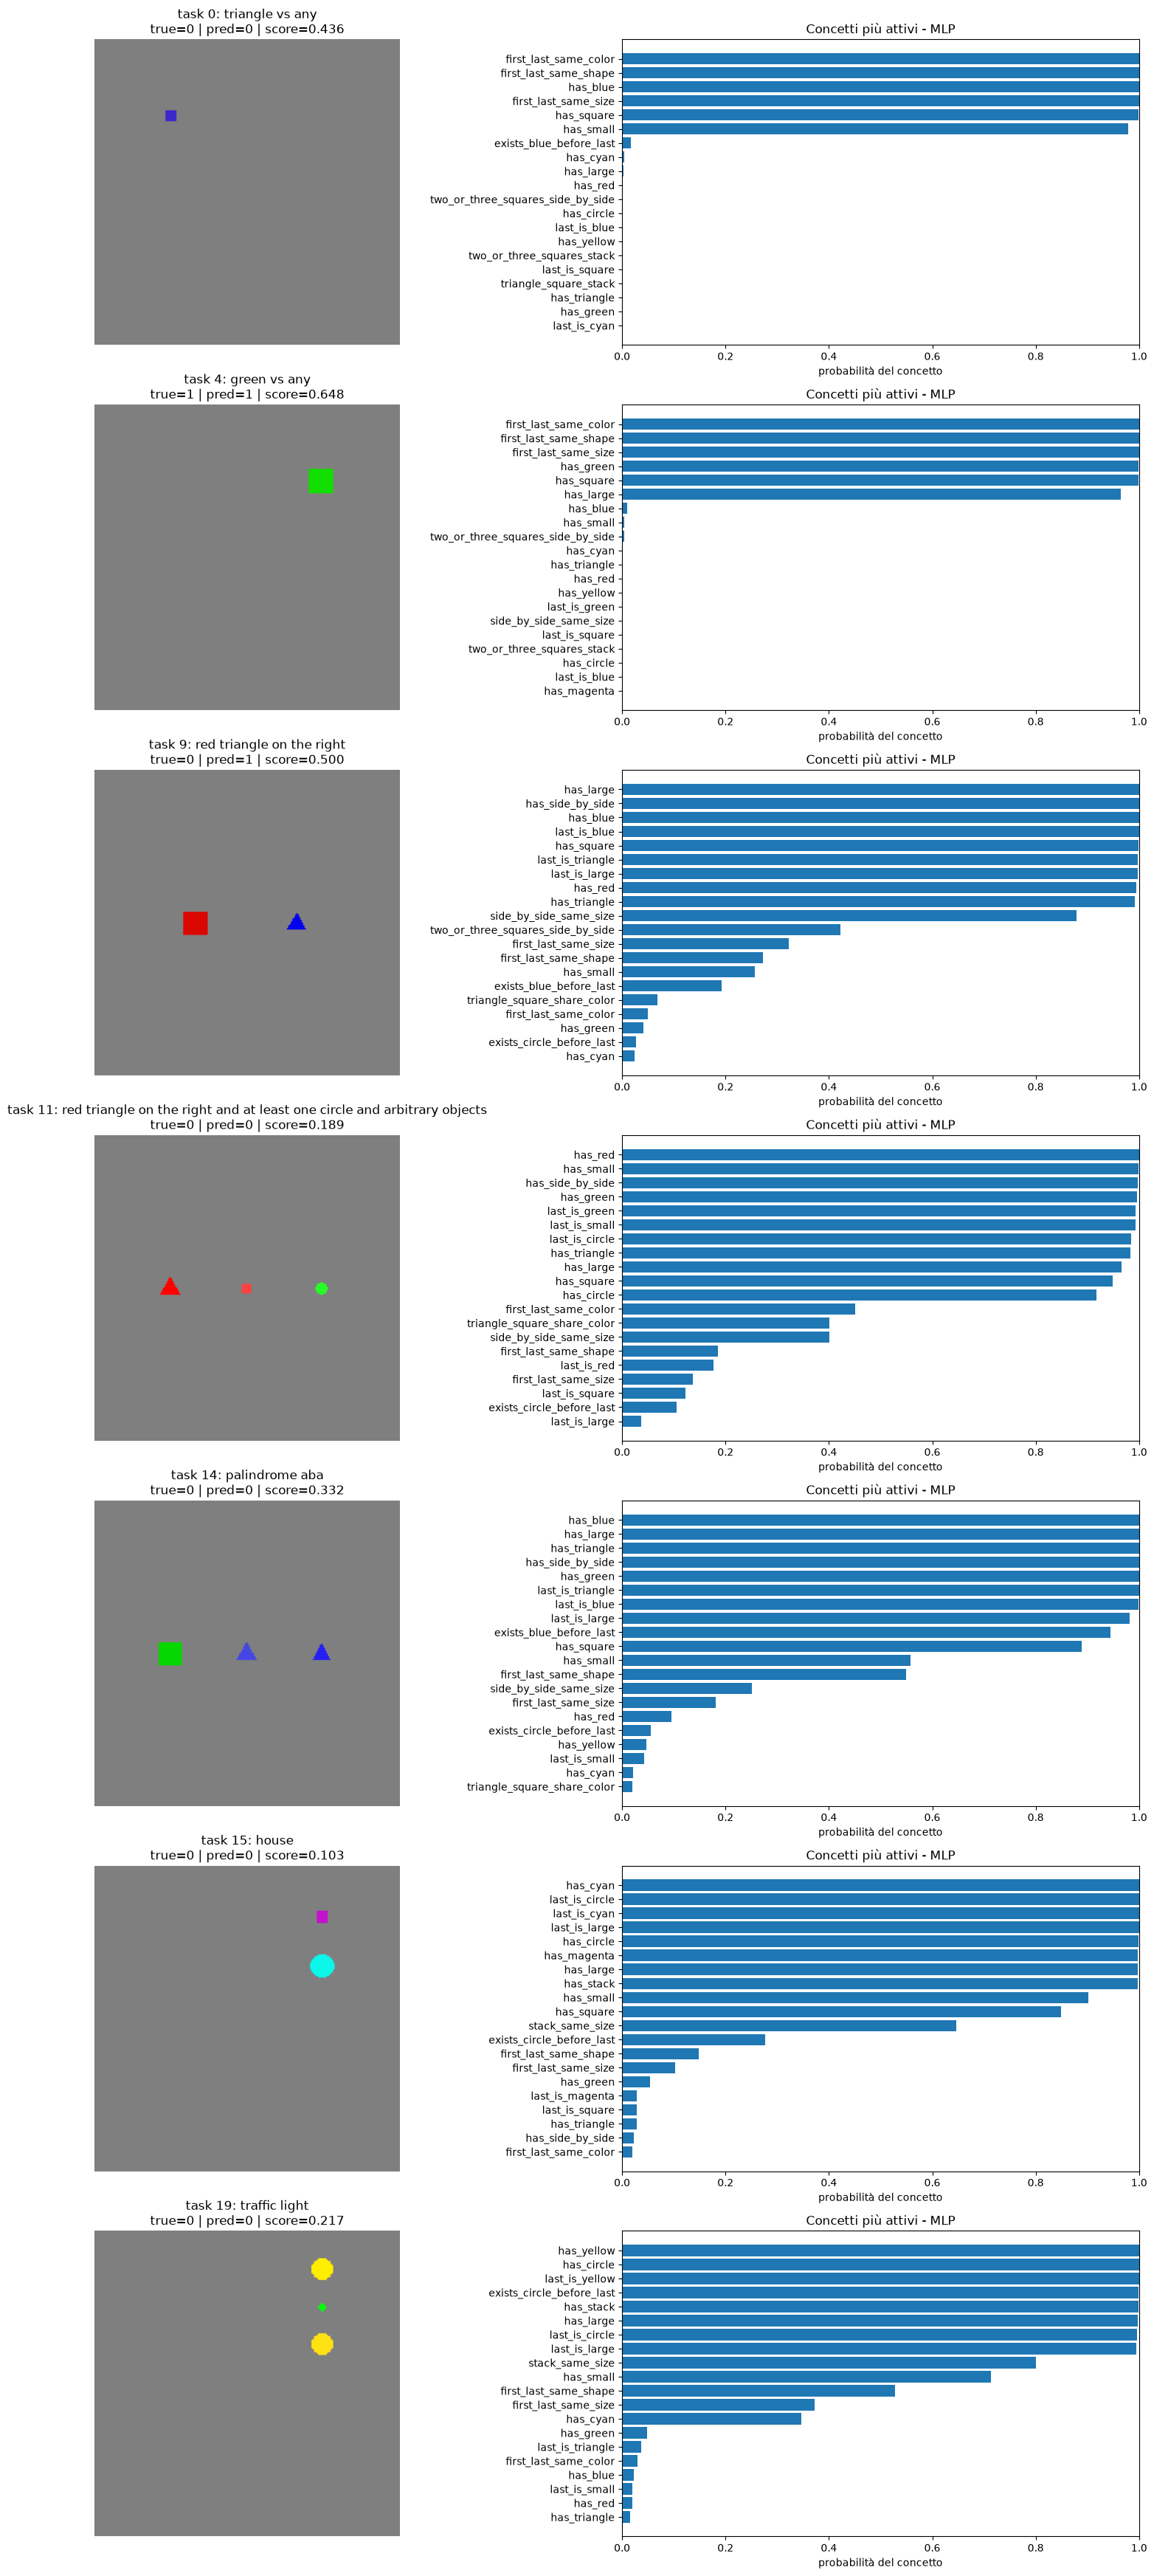

Plot salvato in: /home/cosimo/Downloads/kandy-xai/results/neuro_symbolic_concept_cbm/plots/tasks_concepts_mlp_test_example_5.png


In [40]:
#PROBABILITA CONCETTI MLP

@torch.no_grad()
def show_tasks_concepts_mlp(
    task_ids=tuple(CONFIG["visualization"]["task_ids"]),
    split=CONFIG["visualization"]["split"],
    top_k=CONFIG["visualization"]["top_k"],
    example_idx=CONFIG["visualization"]["mlp_example_idx"],
):
    frame = splits[split].reset_index(
        drop=True
    )

    n = len(task_ids)

    fig = plt.figure(
        figsize=(CONFIG["visualization"]["fig_width"], CONFIG["visualization"]["fig_height_per_task"] * n)
    )

    for row_idx, task_id in enumerate(task_ids):

        task_rows = frame[
            frame["task_id"] == task_id
        ].reset_index(drop=True)

        if len(task_rows) == 0:
            print(
                f"task {task_id} non trovato"
            )
            continue

        if example_idx >= len(task_rows):
            print(
                f"task {task_id}: "
                f"example_idx={example_idx} "
                f"non disponibile "
                f"(esempi disponibili: {len(task_rows)})"
            )
            continue

        row = task_rows.iloc[
            example_idx
        ]

        image_path = (
            SPLIT_DIRS[split]
            / row["filename"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        x = eval_transform(
            image
        ).unsqueeze(0).to(DEVICE)

        _, concept_probs, _ = model_mlp(x)
        #estrae i 37 concetti dalla ResNet senza usare la vecchia testa lineare

        mlp_logits = mlp_head(
            concept_probs
        )
        #usa i concetti con la nuova testa MLP

        concept_probs = (
            concept_probs[0]
            .cpu()
            .numpy()
        )

        task_probs = torch.sigmoid(
            mlp_logits[0]
        ).cpu().numpy()
        #trasforma i logits della MLP in probabilità

        order = np.argsort(
            -concept_probs
        )[:top_k]
        #seleziona i concetti con probabilità più alta

        table = pd.DataFrame(
            {
                "concept": [
                    CONCEPT_NAMES[i]
                    for i in order
                ],
                "probability": [
                    float(concept_probs[i])
                    for i in order
                ],
                "active": [
                    bool(
                        concept_probs[i] >= CONCEPT_THRESHOLD
                    )
                    for i in order
                ],
            }
        )

        predicted = int(
            task_probs[task_id] >= POSITIVE_THRESHOLD
        )

        ax1 = fig.add_subplot(
            n,
            2,
            2 * row_idx + 1,
        )

        ax1.imshow(image)
        ax1.axis("off")

        ax1.set_title(
            f"task {task_id}: "
            f"{TASK_NAMES[task_id]}\n"
            f"true={int(row['label'])} | "
            f"pred={predicted} | "
            f"score={task_probs[task_id]:.3f}"
        )

        ax2 = fig.add_subplot(
            n,
            2,
            2 * row_idx + 2,
        )

        names = table[
            "concept"
        ].iloc[::-1]

        values = table[
            "probability"
        ].iloc[::-1]

        ax2.barh(
            names,
            values,
        )

        ax2.set_xlim(
            0,
            1,
        )

        ax2.set_xlabel(
            "probabilità del concetto"
        )

        ax2.set_title(
            "Concetti più attivi - MLP"
        )

    plt.tight_layout()

    plot_path = (
        PLOTS_DIR
        / CONFIG["outputs"]["mlp_concepts_plot"].format(
            split=split,
            example_idx=example_idx,
        )
    )

    plt.savefig(
        plot_path,
        dpi=CONFIG["visualization"]["dpi"],
        bbox_inches="tight",
    )
    #salva il plot nella cartella dei risultati

    plt.show()
    plt.close(fig)

    print(
        f"Plot salvato in: {plot_path}"
    )


show_tasks_concepts_mlp(
    task_ids=CONFIG["visualization"]["task_ids"],
    split=CONFIG["visualization"]["split"],
    top_k=CONFIG["visualization"]["top_k"],
    example_idx=CONFIG["visualization"]["mlp_example_idx"],
)

## Conclusioni
Possiamo dunque trarre le seguenti conclusioni:

- Il Concept Bottleneck Model mostra che è possibile passare dall'immagine a una rappresentazione composta da concetti semantici interpretabili e utilizzarla per la classificazione finale.

- I 37 concetti si sono dimostrati informativi, soprattutto per attributi semplici come forma e colore, mentre alcune relazioni più strutturate rimangono più difficili da apprendere. 

- La testa lineare raggiunge buone prestazioni, ma la MLP migliora nettamente la capacità di combinare i concetti, arrivando a un'accuracy media di 0.936. 

- Le analisi oracle, di intervento e di robustezza mostrano inoltre che i concetti vengono effettivamente utilizzati dalla classificazione e che i loro errori si propagano in parte all'output finale. 

E, sintetizzando, possiamo dunque affermare che il CBM offre quindi un compromesso tra performance e interpretabilità, mantenendo una rappresentazione intermedia che può essere analizzata e modificata direttamente.